In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Binary Classification based on KDD99 dataset

## Reading the Dataset

In [ ]:
import pandas as pd
# Load the data
file_path = '/content/drive/MyDrive/phd3/NSLKDD_Code/KDDTrain+_20Percent.txt'
df = pd.read_csv(file_path)

## Add columns names

In [ ]:
# Define the list of column names based on the NSL-KDD dataset description
columns = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins',
    'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root',
    'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds',
    'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate',
    'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
    'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
    'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate',
    'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
    'dst_host_srv_rerror_rate', 'attack', 'level'
]

In [ ]:
# Assign the column names to the dataframe
df.columns = columns

In [ ]:
# Convert the attack column to binary labels: 'normal' or 'attack'
df['attack'] = df['attack'].apply(lambda x: 'normal' if x == 'normal' else 'attack')

## Attack Counts over Protocol Types

In [ ]:
# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

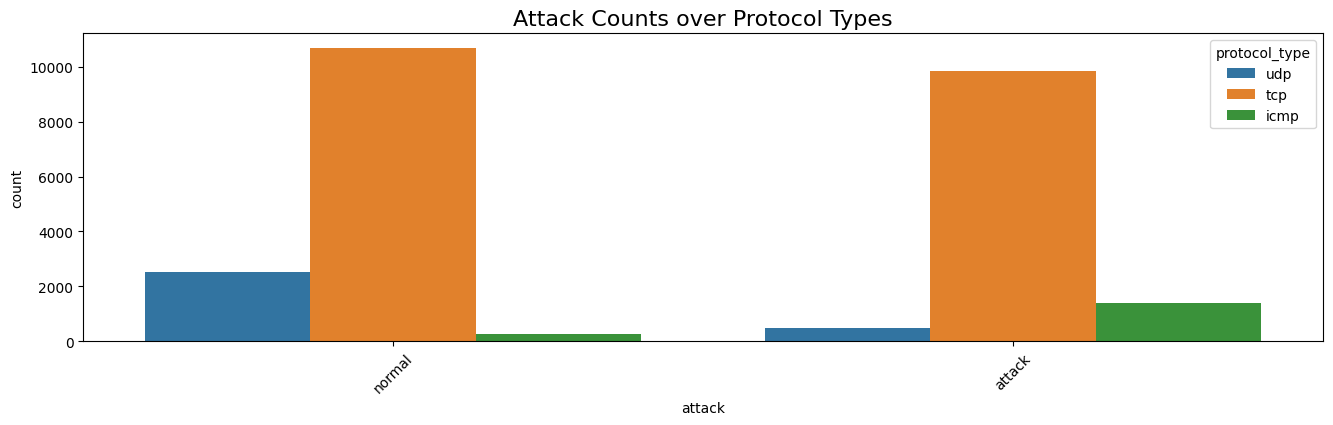

In [ ]:
# Set figure size
plt.figure(figsize=(16, 4))

# Create a count plot of attack types grouped by protocol type
sns.countplot(x='attack', data=df, hue='protocol_type')

# Rotate x-axis labels for readability
plt.xticks(rotation=45)

# Set plot title
plt.title('Attack Counts over Protocol Types', fontdict={'fontsize': 16})

# Show the plot
plt.show()


Class distribution:
attack
normal    13448
attack    11743
Name: count, dtype: int64


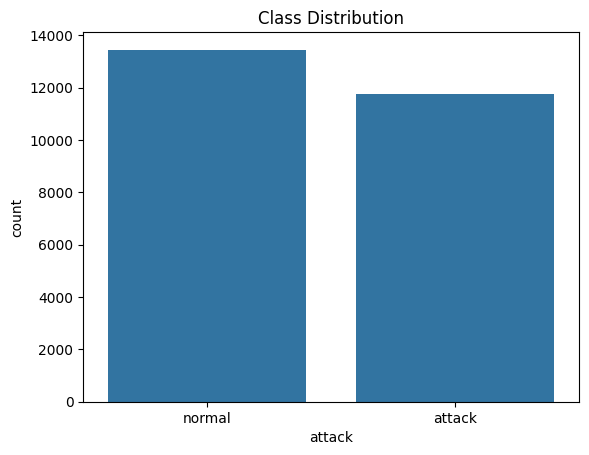

In [ ]:
import seaborn as sns

print("\nClass distribution:")
print(df['attack'].value_counts())

sns.countplot(x='attack', data=df)
plt.title("Class Distribution")
plt.show()


## split data to X and Y

In [ ]:
# Séparation des caractéristiques et de la cible
X = df.drop('attack', axis=1)
y = df['attack']

## Normalize data

In [ ]:
categorical_cols = X.select_dtypes(include=['object']).columns
print(categorical_cols)

Index(['protocol_type', 'service', 'flag'], dtype='object')


In [ ]:
X_encoded = pd.get_dummies(X, columns=categorical_cols)
# Turn y into binary: 0 = normal, 1 = attack
#y_binary = y.apply(lambda x: 0 if x == 'normal' else 1)

## Pytorch

In [ ]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from imblearn.over_sampling import SMOTE



In [ ]:
from sklearn.preprocessing import StandardScaler
# Normalisation des données
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

In [ ]:
# 🔤 Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y) # 0 = attack , 1 = normal
#y_bin_encoded = label_encoder.fit_transform(y_binary)

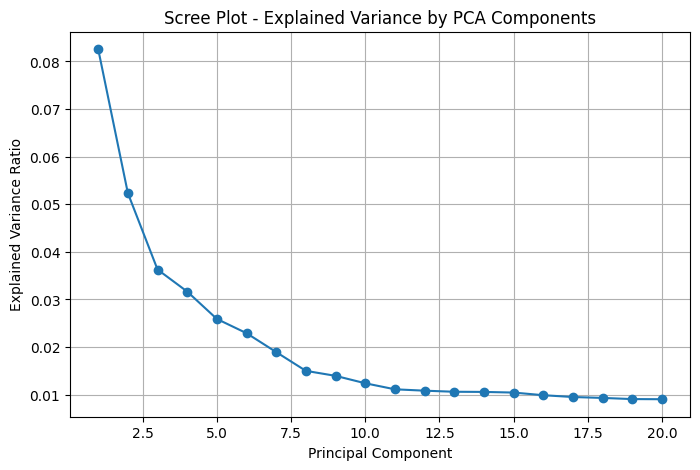

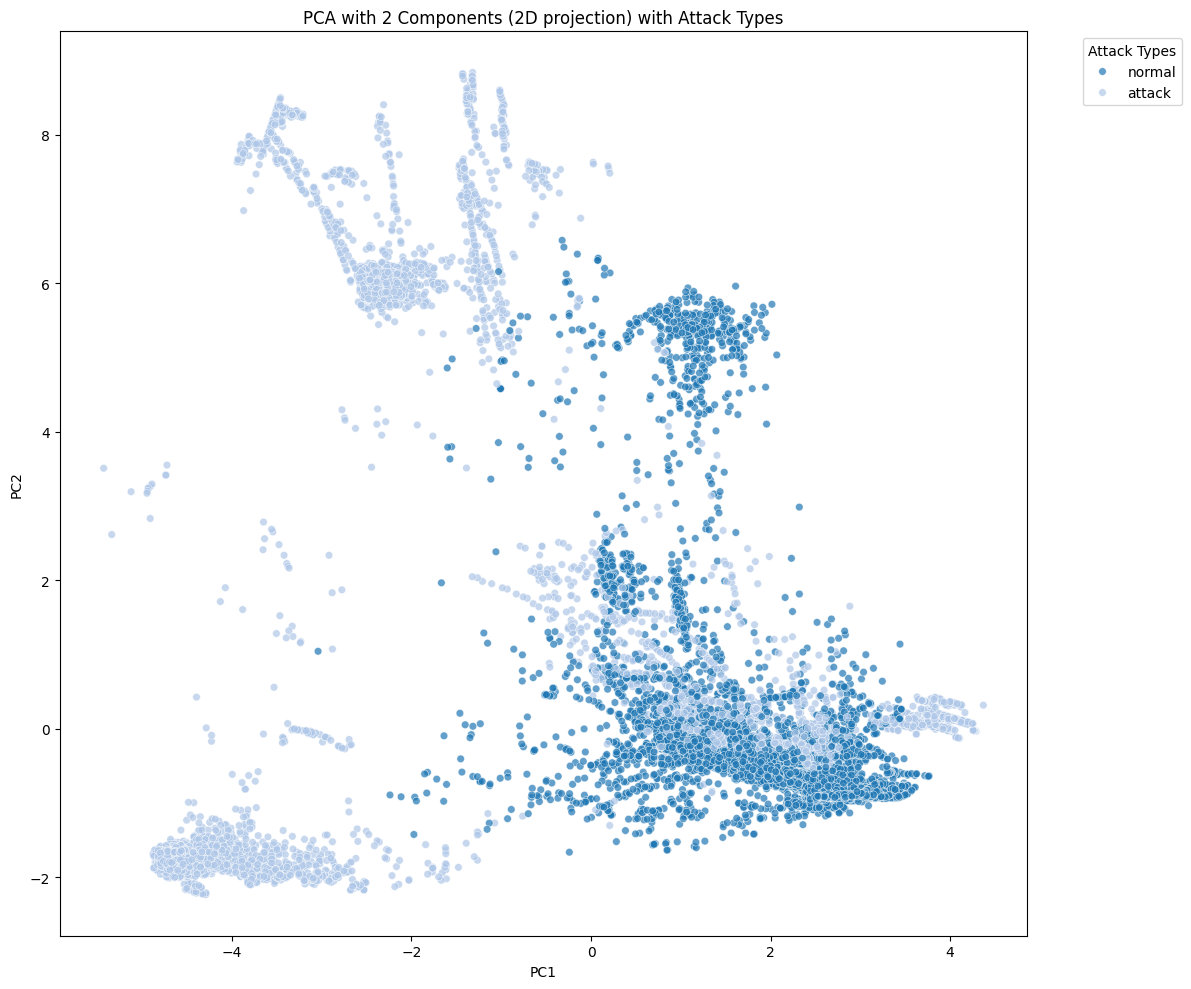

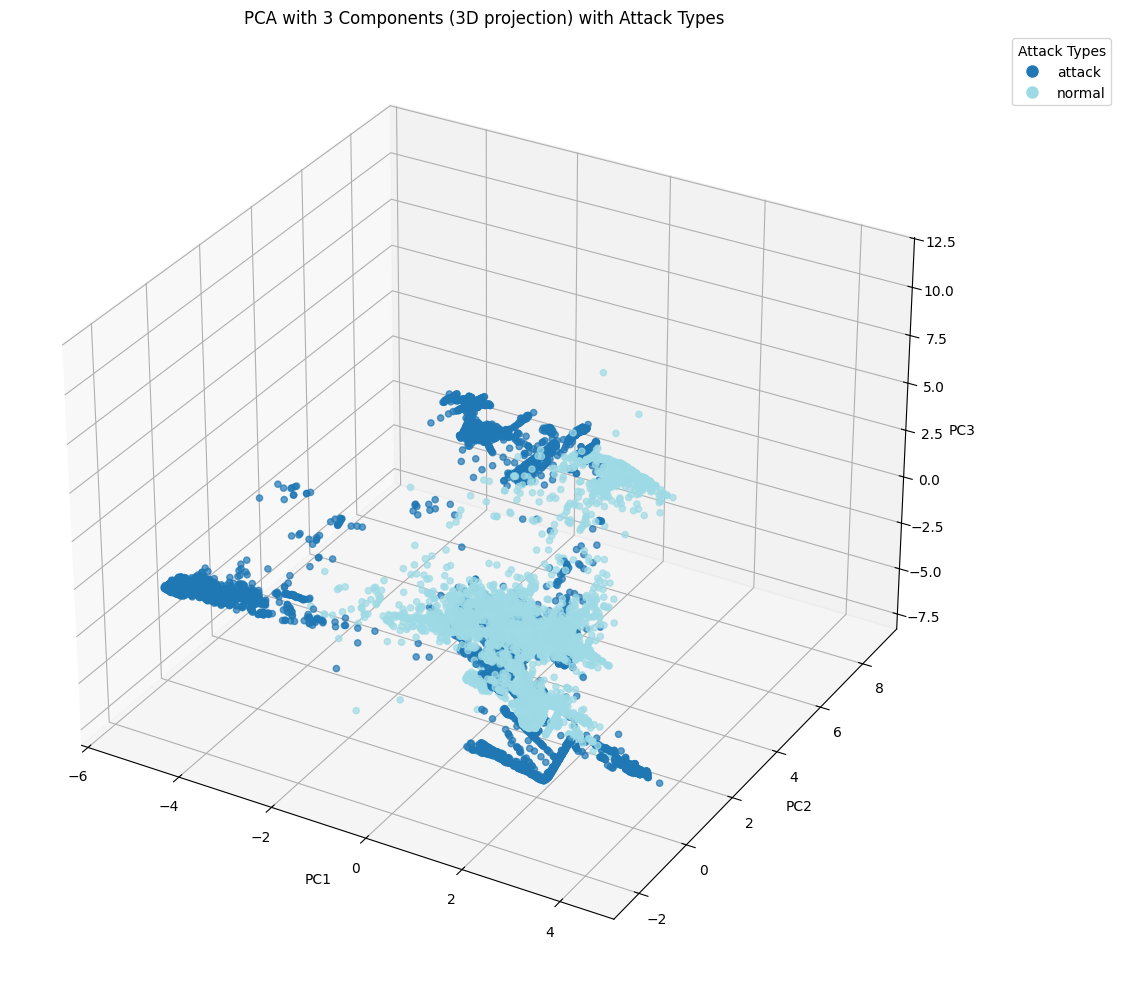

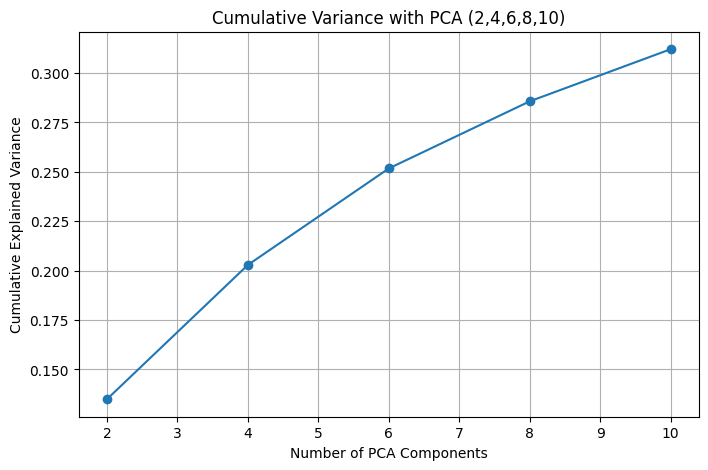

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler # StandardScaler is already imported in the first cell, but keeping it here for clarity if this cell is run independently
from mpl_toolkits.mplot3d import Axes3D

# Use the already scaled data X_scaled
# X = features, y = labels
# Suppose X_scaled is your scaled feature matrix, y your labels (normal/attack or multiclass)

# We need to refit the encoder as it was applied earlier in the notebook
label_encoder = LabelEncoder()
label_encoder.fit(df['attack'])
# Create a mapping from numerical labels to the original string labels
original_nsl_labels_map = dict(zip(label_encoder.transform(label_encoder.classes_), label_encoder.classes_))

# Map numerical labels to original string labels for plotting
y_labels = [original_nsl_labels_map[label_val] for label_val in y_encoded]

# -------------------------------
# 1. Explained Variance (Scree Plot)
# -------------------------------
pca = PCA(n_components=20)   # take first 20 components
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,5))
plt.plot(range(1, 21), pca.explained_variance_ratio_, marker='o')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot - Explained Variance by PCA Components')
plt.grid(True)
plt.savefig('/content/drive/MyDrive/phd3/plots/scree_plot_NSLKDD.png', dpi=300, bbox_inches='tight') # Save Scree Plot
plt.show()

# -------------------------------
# 2. 2D PCA Scatter Plot
# -------------------------------
pca_2 = PCA(n_components=2)
X_pca2 = pca_2.fit_transform(X_scaled)

plt.figure(figsize=(12,10)) # Increase figure size for better readability
sns.scatterplot(x=X_pca2[:,0], y=X_pca2[:,1], hue=y_labels, palette="tab20", s=30, alpha=0.7) # Use y_labels and a different palette
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA with 2 Components (2D projection) with Attack Types')
plt.legend(title="Attack Types", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() # Adjust layout to prevent labels overlapping
plt.savefig('/content/drive/MyDrive/phd3/plots/pca_2d_plot_NSLKDD.png', dpi=300, bbox_inches='tight') # Save 2D PCA plot
plt.show()

# -------------------------------
# 3. 3D PCA Scatter Plot (optional)
# -------------------------------
pca_3 = PCA(n_components=3)
X_pca3 = pca_3.fit_transform(X_scaled)

fig = plt.figure(figsize=(12,10)) # Increase figure size for better readability
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X_pca3[:,0], X_pca3[:,1], X_pca3[:,2], c=y_encoded, cmap='tab20', s=20, alpha=0.7) # Keep numerical labels for color mapping, use y_labels for legend
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
plt.title('PCA with 3 Components (3D projection) with Attack Types')
# Manually create legend with string labels
legend_elements = [plt.Line2D([0], [0], marker='o', color='w', label=original_nsl_labels_map[label_value],
                              markerfacecolor=scatter.cmap(scatter.norm(label_value)), markersize=10)
                   for label_value in sorted(original_nsl_labels_map.keys())]
ax.legend(handles=legend_elements, title="Attack Types", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() # Adjust layout to prevent labels overlapping
plt.savefig('/content/drive/MyDrive/phd3/plots/pca_3d_plot.png', dpi=300, bbox_inches='tight') # Save 3D PCA plot
plt.show()


# -------------------------------
# 4. Cumulative Explained Variance (for 2,4,6,8,10 components)
# -------------------------------
components_list = [2,4,6,8,10]
explained_variances = []

for n in components_list:
    pca_n = PCA(n_components=n)
    pca_n.fit(X_scaled)
    explained_variances.append(sum(pca_n.explained_variance_ratio_))

plt.figure(figsize=(8,5))
plt.plot(components_list, explained_variances, marker='o')
plt.xlabel('Number of PCA Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Variance with PCA (2,4,6,8,10)')
plt.grid(True)
plt.savefig('/content/drive/MyDrive/phd3/plots/cumulative_variance_plot_NSLKDD.png', dpi=300, bbox_inches='tight') # Save Cumulative Variance plot
plt.show()

# **CICIDS DDOS dataset**

In [ ]:
import pandas as pd
import numpy as np
from sklearn import preprocessing
import matplotlib.pyplot as plt
%matplotlib inline
import os
                    #'/content/drive/MyDrive/phd3/cicids2017_Code/CICIDS_2017_DDOS.csv
data = pd.read_csv('/content/drive/MyDrive/phd3/cicids2017_Code/Cicids_2017_DDOS/CICIDS_2017_DDOS.csv')

In [ ]:
data.drop('Label', axis = 1, inplace = True)

In [ ]:
# For improving performance and reduce memory-related errors
old_memory_usage = data.memory_usage().sum() / 1024 ** 2
print(f'Initial memory usage: {old_memory_usage:.2f} MB')
for col in data.columns:
    col_type = data[col].dtype
    if col_type != object:
        c_min = data[col].min()
        c_max = data[col].max()
        # Downcasting float64 to float32
        if str(col_type).find('float') >= 0 and c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
            data[col] = data[col].astype(np.float32)

        # Downcasting int64 to int32
        elif str(col_type).find('int') >= 0 and c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
            data[col] = data[col].astype(np.int32)

new_memory_usage = data.memory_usage().sum() / 1024 ** 2
print(f"Final memory usage: {new_memory_usage:.2f} MB")

Initial memory usage: 117.45 MB
Final memory usage: 59.58 MB


In [ ]:
data['Attack Type'] = data['Attack Type'].apply(lambda x: 'normal' if x == 'BENIGN' else 'attack')

In [ ]:
new_data = data

In [ ]:
new_data.shape

(223112, 69)

In [ ]:
# Creating a balanced dataset for Binary Classification
#new_data = data
normal_traffic = new_data.loc[new_data['Attack Type'] == 'normal']
intrusions = new_data.loc[new_data['Attack Type'] == 'attack']

normal_traffic = normal_traffic.sample(n = len(intrusions), replace = True,random_state = 42)

ids_data = pd.concat([intrusions, normal_traffic])
ids_data['Attack Type'] = np.where((ids_data['Attack Type'] == 'normal'), 0, 1)
bc_data = ids_data.sample(n = 25000)

print(bc_data['Attack Type'].value_counts())

Attack Type
0    12519
1    12481
Name: count, dtype: int64


In [ ]:
# Séparation des caractéristiques et de la cible
X = bc_data.drop('Attack Type', axis=1)
# Convert the attack column to binary labels: 'normal' or 'attack'
y = bc_data['Attack Type']

In [ ]:
# Séparation des caractéristiques et de la cible
X = new_data.drop('Attack Type', axis=1)
# Convert the attack column to binary labels: 'normal' or 'attack'
y = new_data['Attack Type']

In [ ]:
from sklearn.preprocessing import StandardScaler
# Normalisation des données
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# 🔤 Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y) # 0 = attack , 1 = normal
#y_bin_encoded = label_encoder.fit_transform(y_binary)

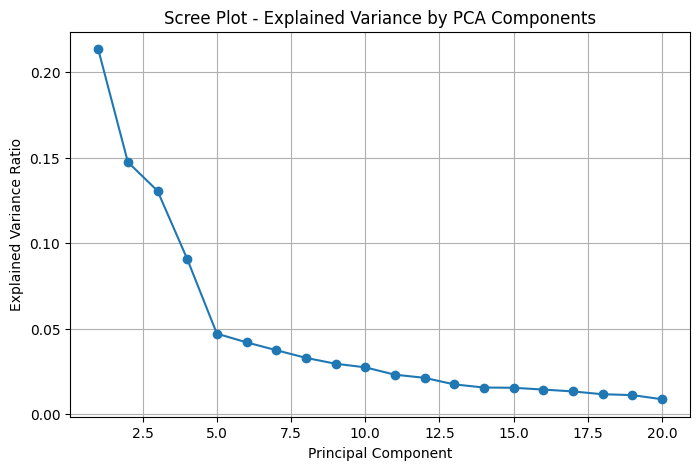

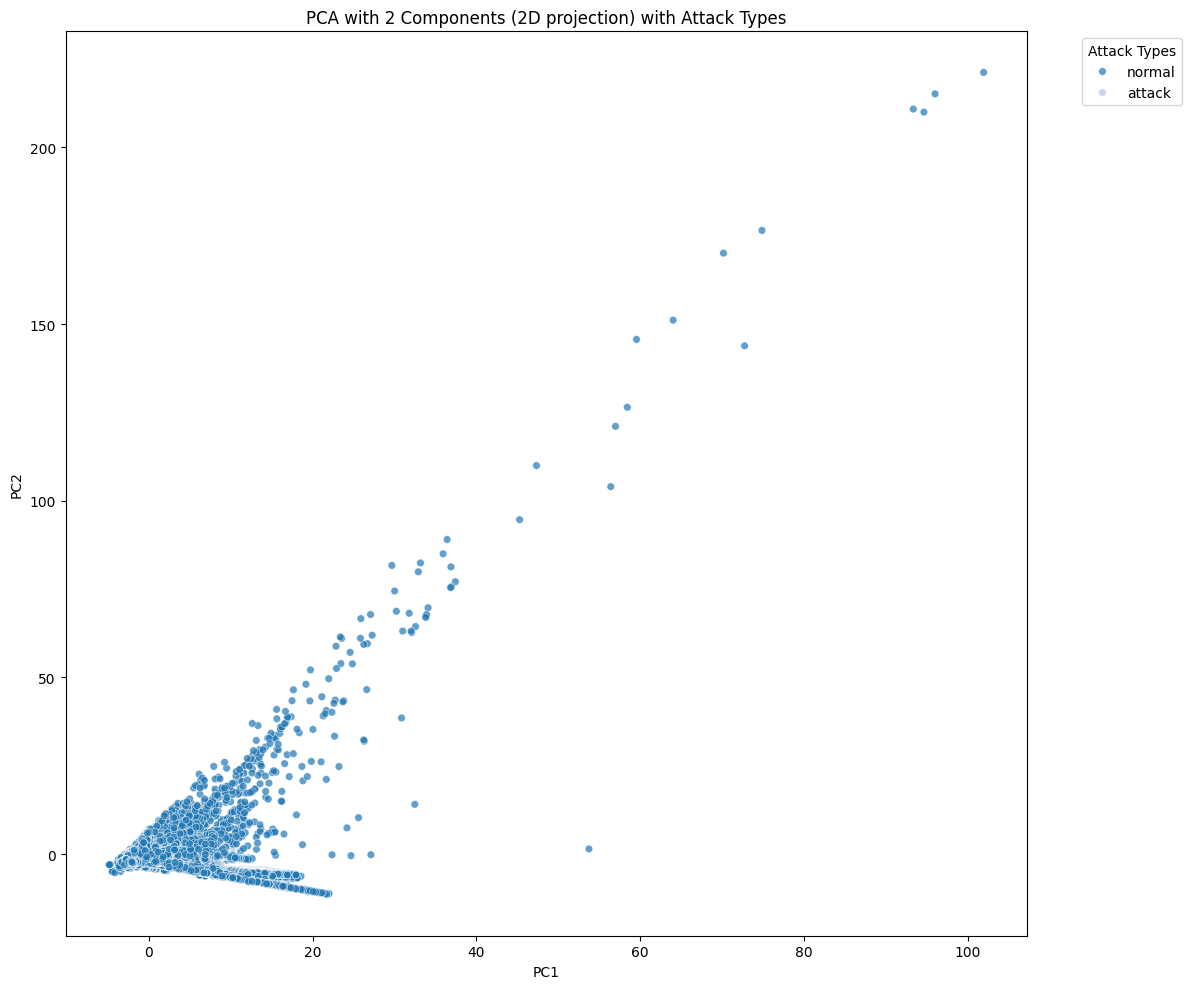

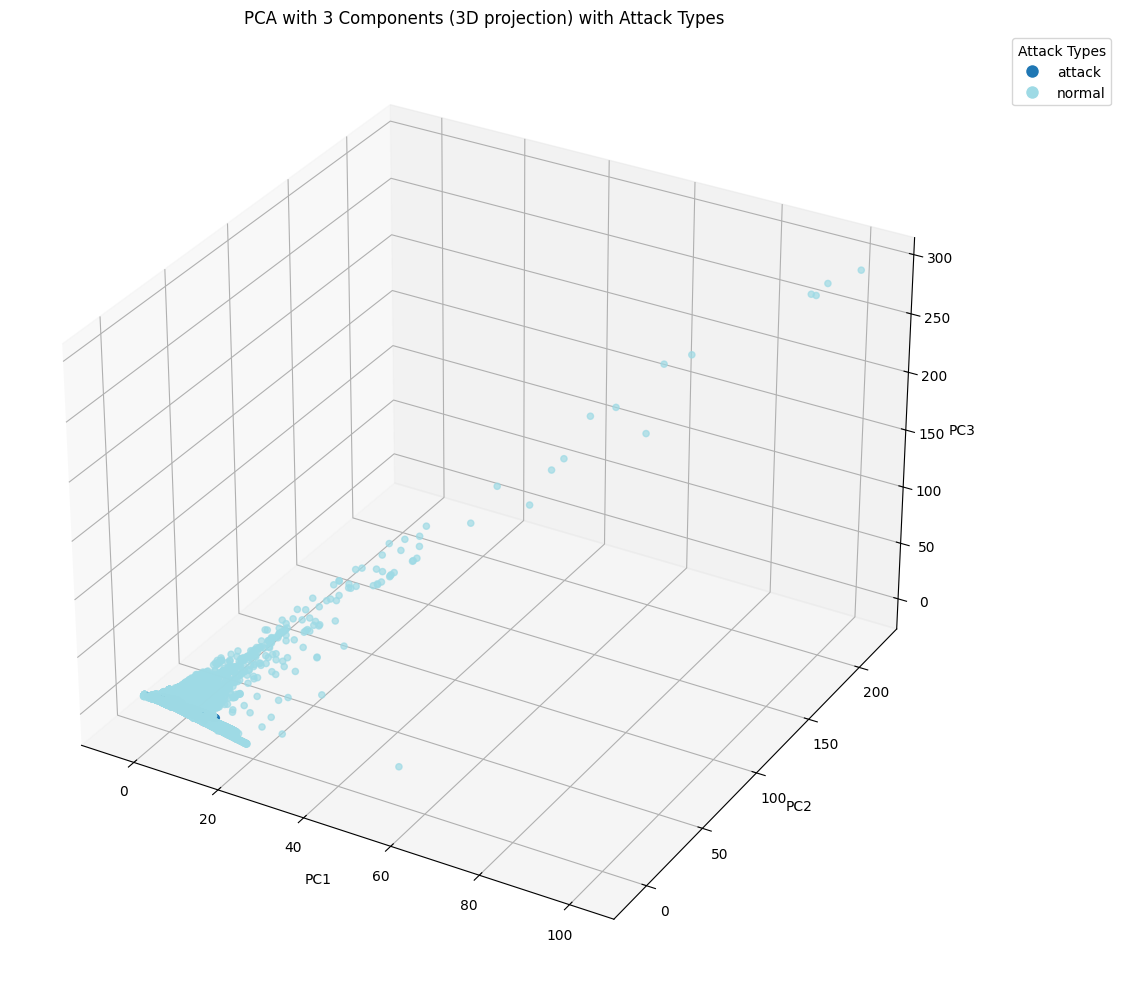

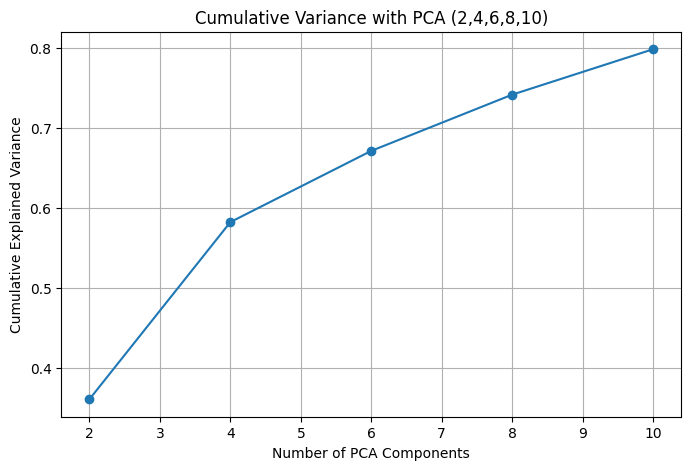

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler # StandardScaler is already imported in the first cell, but keeping it here for clarity if this cell is run independently
from mpl_toolkits.mplot3d import Axes3D

# Use the already scaled data X_scaled
# X = features, y = labels
# Suppose X_scaled is your scaled feature matrix, y your labels (normal/attack or multiclass)

# We need to refit the encoder as it was applied earlier in the notebook
label_encoder = LabelEncoder()
label_encoder.fit(new_data['Attack Type']) # Corrected from 'attack' to 'Attack Type'
# Create a mapping from numerical labels to the original string labels
original_nsl_labels_map = dict(zip(label_encoder.transform(label_encoder.classes_), label_encoder.classes_))

# Map numerical labels to original string labels for plotting
y_labels = [original_nsl_labels_map[label_val] for label_val in y_encoded]

# -------------------------------
# 1. Explained Variance (Scree Plot)
# -------------------------------
pca = PCA(n_components=20)   # take first 20 components
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,5))
plt.plot(range(1, 21), pca.explained_variance_ratio_, marker='o')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot - Explained Variance by PCA Components')
plt.grid(True)
plt.savefig('/content/drive/MyDrive/phd3/plots/scree_plot_CICIDSDDOS.png', dpi=300, bbox_inches='tight') # Save Scree Plot
plt.show()

# -------------------------------
# 2. 2D PCA Scatter Plot
# -------------------------------
pca_2 = PCA(n_components=2)
X_pca2 = pca_2.fit_transform(X_scaled)

plt.figure(figsize=(12,10)) # Increase figure size for better readability
sns.scatterplot(x=X_pca2[:,0], y=X_pca2[:,1], hue=y_labels, palette="tab20", s=30, alpha=0.7) # Use y_labels and a different palette
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA with 2 Components (2D projection) with Attack Types')
plt.legend(title="Attack Types", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() # Adjust layout to prevent labels overlapping
plt.savefig('/content/drive/MyDrive/phd3/plots/pca_2d_plot_CICIDSDDOS.png', dpi=300, bbox_inches='tight') # Save 2D PCA plot
plt.show()

# -------------------------------
# 3. 3D PCA Scatter Plot (optional)
# -------------------------------
pca_3 = PCA(n_components=3)
X_pca3 = pca_3.fit_transform(X_scaled)

fig = plt.figure(figsize=(12,10)) # Increase figure size for better readability
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X_pca3[:,0], X_pca3[:,1], X_pca3[:,2], c=y_encoded, cmap='tab20', s=20, alpha=0.7) # Keep numerical labels for color mapping, use y_labels for legend
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
plt.title('PCA with 3 Components (3D projection) with Attack Types')
# Manually create legend with string labels
legend_elements = [plt.Line2D([0], [0], marker='o', color='w', label=original_nsl_labels_map[label_value],
                              markerfacecolor=scatter.cmap(scatter.norm(label_value)), markersize=10)
                   for label_value in sorted(original_nsl_labels_map.keys())]
ax.legend(handles=legend_elements, title="Attack Types", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() # Adjust layout to prevent labels overlapping
plt.savefig('/content/drive/MyDrive/phd3/plots/pca_3d_plot_CICIDSDDOS.png', dpi=300, bbox_inches='tight') # Save 3D PCA plot
plt.show()


# -------------------------------
# 4. Cumulative Explained Variance (for 2,4,6,8,10 components)
# -------------------------------
components_list = [2,4,6,8,10]
explained_variances = []

for n in components_list:
    pca_n = PCA(n_components=n)
    pca_n.fit(X_scaled)
    explained_variances.append(sum(pca_n.explained_variance_ratio_))

plt.figure(figsize=(8,5))
plt.plot(components_list, explained_variances, marker='o')
plt.xlabel('Number of PCA Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Variance with PCA (2,4,6,8,10)')
plt.grid(True)
plt.savefig('/content/drive/MyDrive/phd3/plots/cumulative_variance_plot_CICIDSDDOS.png', dpi=300, bbox_inches='tight') # Save Cumulative Variance plot
plt.show()

# **CICIDS full dataset**

In [ ]:

import pandas as pd
import numpy as np
from sklearn import preprocessing
import matplotlib.pyplot as plt
%matplotlib inline
import os

data = pd.read_csv('/content/drive/MyDrive/phd3/cicids2017_Code/dataset.csv')

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler # StandardScaler is already imported in the first cell, but keeping it here for clarity if this cell is run independently
from mpl_toolkits.mplot3d import Axes3D

# Use the already scaled data X_scaled
# X = features, y = labels
# Suppose X_scaled is your scaled feature matrix, y your labels (normal/attack or multiclass)

# We need to refit the encoder as it was applied earlier in the notebook
label_encoder = LabelEncoder()
label_encoder.fit(new_data['Attack Type']) # Corrected from 'attack' to 'Attack Type'
# Create a mapping from numerical labels to the original string labels
original_nsl_labels_map = dict(zip(label_encoder.transform(label_encoder.classes_), label_encoder.classes_))

# Map numerical labels to original string labels for plotting
y_labels = [original_nsl_labels_map[label_val] for label_val in y_encoded]

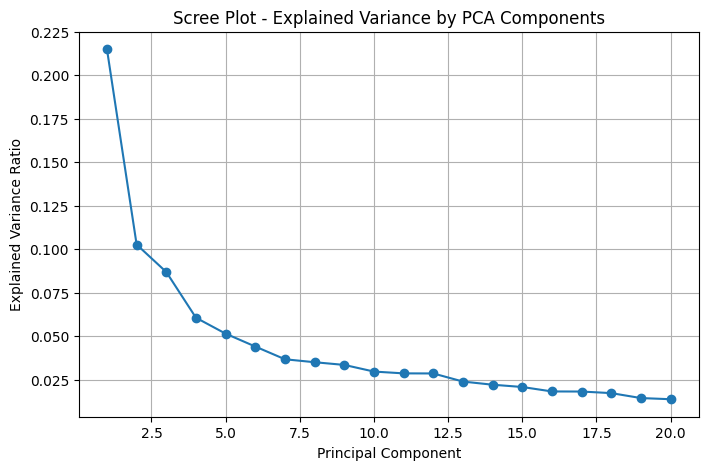

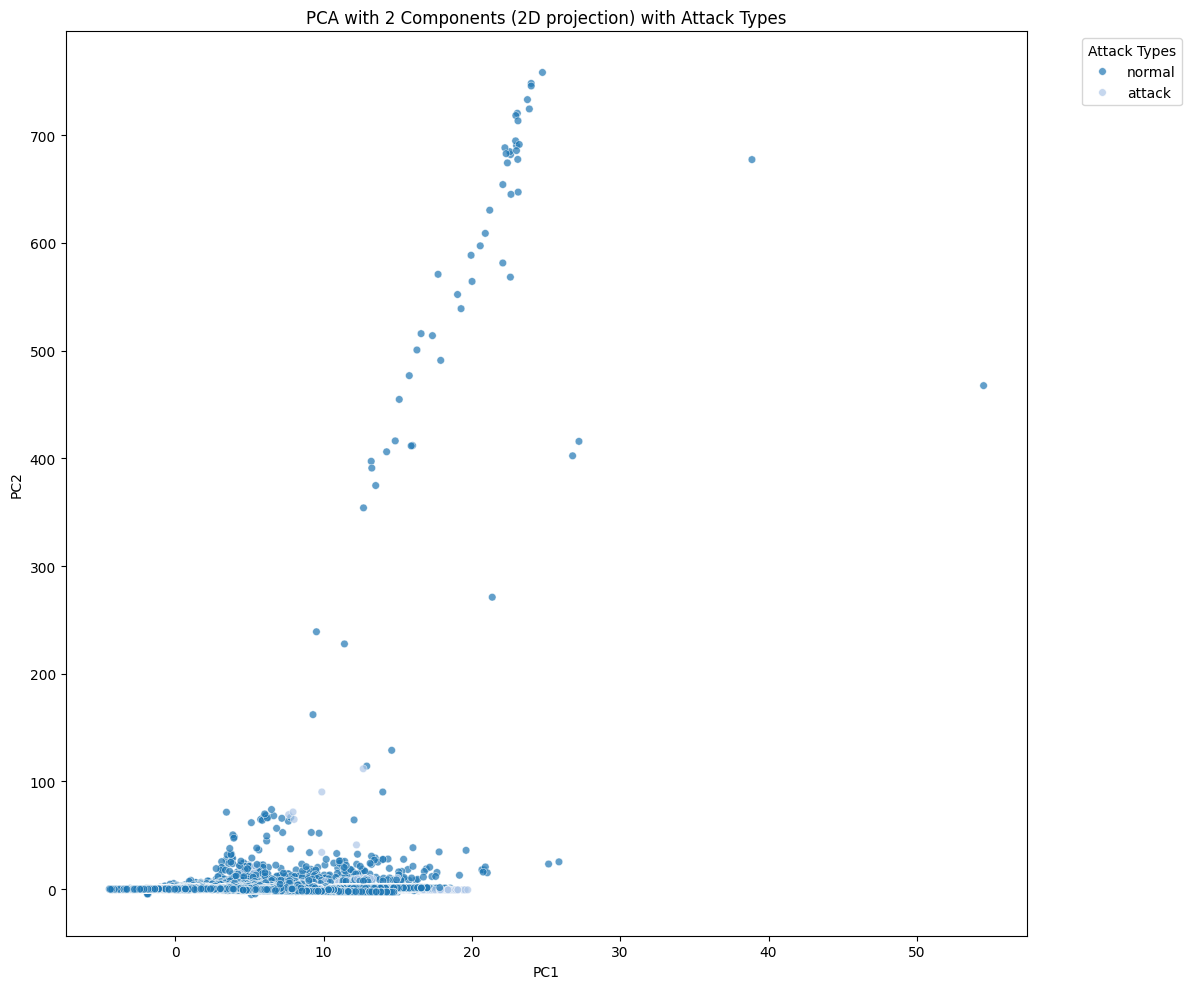

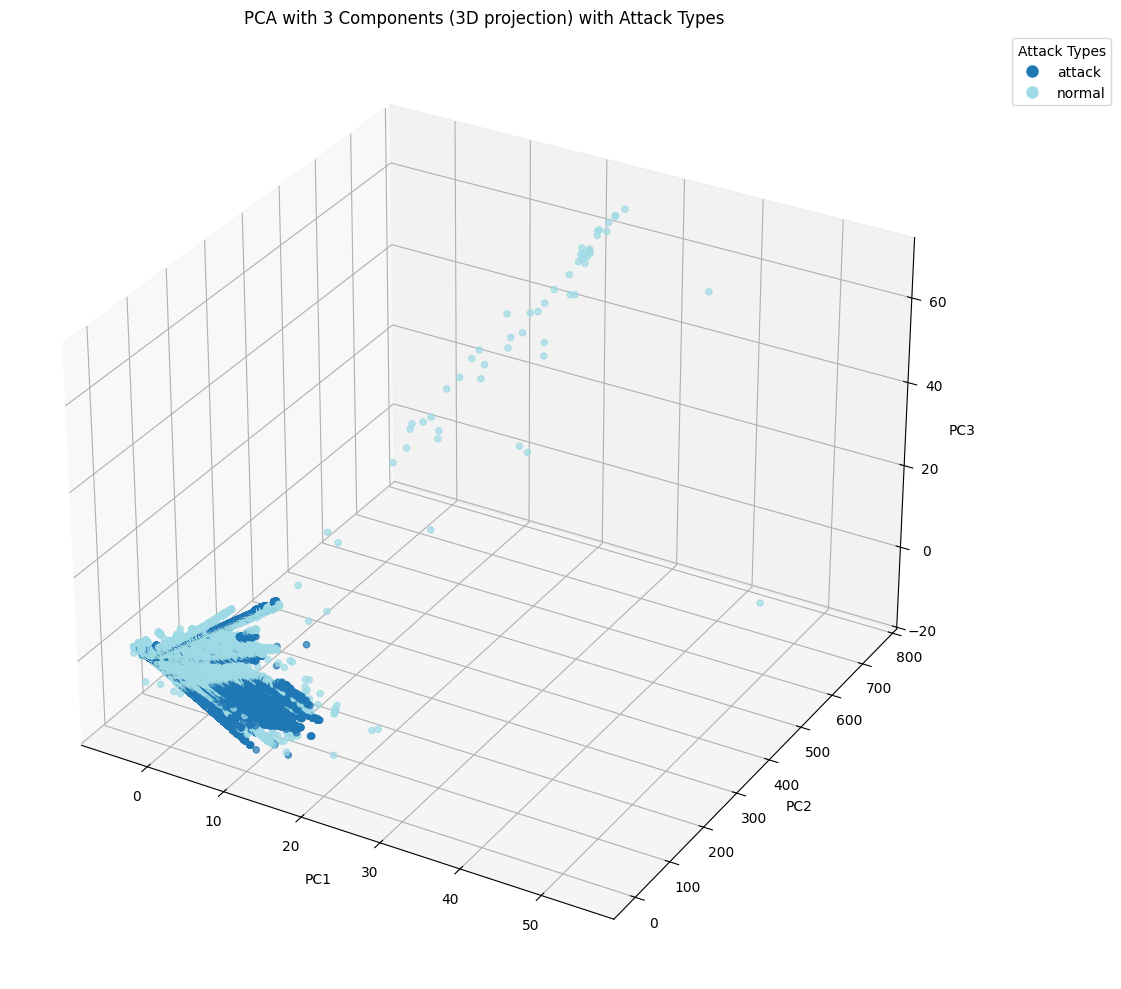

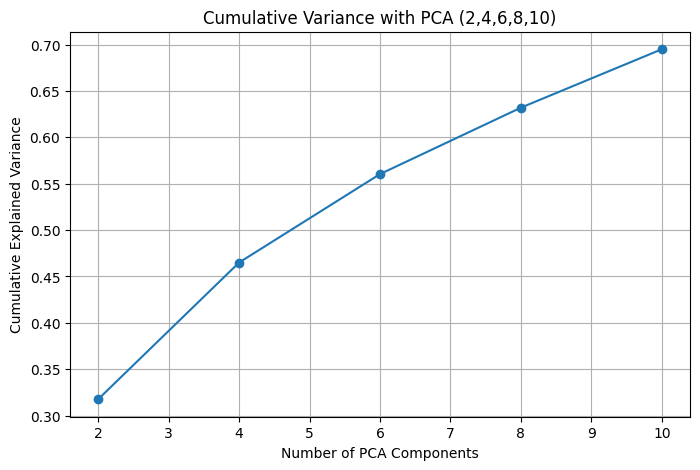

In [ ]:


# -------------------------------
# 1. Explained Variance (Scree Plot)
# -------------------------------
pca = PCA(n_components=20)   # take first 20 components
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,5))
plt.plot(range(1, 21), pca.explained_variance_ratio_, marker='o')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot - Explained Variance by PCA Components')
plt.grid(True)
plt.savefig('/content/drive/MyDrive/phd3/plots/scree_plot_CICIDS.png', dpi=300, bbox_inches='tight') # Save Scree Plot
plt.show()

# -------------------------------
# 2. 2D PCA Scatter Plot
# -------------------------------
pca_2 = PCA(n_components=2)
X_pca2 = pca_2.fit_transform(X_scaled)

plt.figure(figsize=(12,10)) # Increase figure size for better readability
sns.scatterplot(x=X_pca2[:,0], y=X_pca2[:,1], hue=y_labels, palette="tab20", s=30, alpha=0.7) # Use y_labels and a different palette
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA with 2 Components (2D projection) with Attack Types')
plt.legend(title="Attack Types", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() # Adjust layout to prevent labels overlapping
plt.savefig('/content/drive/MyDrive/phd3/plots/pca_2d_plot_CICIDS.png', dpi=300, bbox_inches='tight') # Save 2D PCA plot
plt.show()

# -------------------------------
# 3. 3D PCA Scatter Plot (optional)
# -------------------------------
pca_3 = PCA(n_components=3)
X_pca3 = pca_3.fit_transform(X_scaled)

fig = plt.figure(figsize=(12,10)) # Increase figure size for better readability
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X_pca3[:,0], X_pca3[:,1], X_pca3[:,2], c=y_encoded, cmap='tab20', s=20, alpha=0.7) # Keep numerical labels for color mapping, use y_labels for legend
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
plt.title('PCA with 3 Components (3D projection) with Attack Types')
# Manually create legend with string labels
legend_elements = [plt.Line2D([0], [0], marker='o', color='w', label=original_nsl_labels_map[label_value],
                              markerfacecolor=scatter.cmap(scatter.norm(label_value)), markersize=10)
                   for label_value in sorted(original_nsl_labels_map.keys())]
ax.legend(handles=legend_elements, title="Attack Types", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() # Adjust layout to prevent labels overlapping
plt.savefig('/content/drive/MyDrive/phd3/plots/pca_3d_plot_CICIDS.png', dpi=300, bbox_inches='tight') # Save 3D PCA plot
plt.show()


# -------------------------------
# 4. Cumulative Explained Variance (for 2,4,6,8,10 components)
# -------------------------------
components_list = [2,4,6,8,10]
explained_variances = []

for n in components_list:
    pca_n = PCA(n_components=n)
    pca_n.fit(X_scaled)
    explained_variances.append(sum(pca_n.explained_variance_ratio_))

plt.figure(figsize=(8,5))
plt.plot(components_list, explained_variances, marker='o')
plt.xlabel('Number of PCA Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Variance with PCA (2,4,6,8,10)')
plt.grid(True)
plt.savefig('/content/drive/MyDrive/phd3/plots/cumulative_variance_plot_CICIDS.png', dpi=300, bbox_inches='tight') # Save Cumulative Variance plot
plt.show()

# **Results**

In [ ]:
import pandas as pd

df_classical = pd.DataFrame(results["metrics_classical"])
df_hybrid = pd.DataFrame(results["metrics_hybrid"])

print(df_classical.head())


NameError: name 'results' is not defined

ValueError: setting an array element with a sequence.

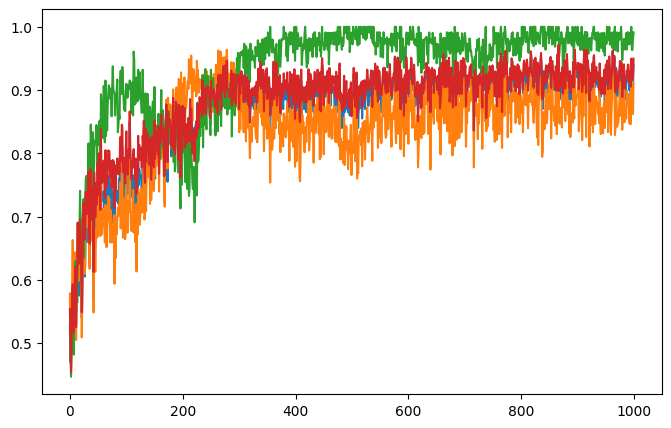

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
for col in df_classical.columns:
    plt.plot(df_classical[col], label=f"Classical {col}")

for col in df_hybrid.columns:
    plt.plot(df_hybrid[col], '--', label=f"Hybrid {col}")

plt.xlabel("Episode")
plt.ylabel("Metric Value")
plt.title("Classical vs Hybrid QRL Performance")
plt.legend()
plt.show()


In [ ]:
last_classical = df_classical.iloc[-1]
last_hybrid = df_hybrid.iloc[-1]

summary = pd.DataFrame({
    "Classical": last_classical,
    "Hybrid QRL": last_hybrid
})
print(summary)


                             Classical            Hybrid QRL
accuracy                          0.94                 0.915
precision                      0.91129               0.87931
recall                        0.991228              0.971429
f1                             0.94958              0.923077
confusion_matrix  [[75, 11], [1, 113]]  [[81, 14], [3, 102]]


# **Results Concatination part**

In [ ]:
import pickle
import os
import pandas as pd
import matplotlib.pyplot as plt


# =====================
# 1️⃣ Load the results file
# =====================
OUTPUT_DIR = "/content/drive/MyDrive/phd3/outputs/NSLKDD_Resutls/AngleEmbedding/Angle-pca2/"
with open(os.path.join(OUTPUT_DIR, "qrl_ids_results.pkl"), "rb") as f:
    results = pickle.load(f)


# =====================
# 1️⃣ Load the results file
# =====================
OUTPUT_DIR = "/content/drive/MyDrive/phd3/outputs/NSLKDD_Resutls/IQPEmbedding/IQP-pca2/"
with open(os.path.join(OUTPUT_DIR, "qrl_ids_results.pkl"), "rb") as f:
    results = pickle.load(f)

In [ ]:
results

{'rewards_classical': [48.0,
  93.0,
  90.0,
  50.0,
  97.0,
  88.5,
  71.5,
  142.5,
  124.0,
  99.0,
  120.0,
  124.5,
  105.0,
  107.0,
  119.5,
  137.5,
  68.0,
  118.0,
  151.0,
  156.5,
  136.5,
  137.5,
  169.0,
  115.5,
  144.0,
  148.5,
  187.0,
  144.5,
  152.0,
  109.0,
  198.0,
  177.0,
  163.0,
  154.5,
  137.0,
  155.0,
  160.0,
  208.5,
  140.5,
  158.5,
  168.0,
  171.0,
  207.0,
  209.5,
  143.5,
  157.0,
  182.5,
  181.0,
  190.0,
  212.5,
  173.0,
  188.5,
  174.0,
  160.5,
  172.0,
  172.5,
  193.0,
  188.0,
  154.0,
  204.0,
  190.5,
  198.5,
  170.5,
  214.0,
  177.0,
  174.5,
  180.5,
  227.0,
  193.0,
  201.5,
  218.0,
  207.0,
  186.0,
  187.5,
  204.5,
  228.0,
  217.0,
  208.5,
  203.0,
  207.5,
  217.5,
  213.5,
  206.5,
  242.0,
  238.5,
  195.0,
  231.5,
  220.0,
  252.0,
  227.5,
  232.0,
  228.5,
  213.0,
  235.5,
  229.0,
  223.5,
  226.5,
  241.5,
  232.0,
  210.5,
  239.0,
  246.5,
  246.0,
  226.5,
  228.5,
  256.5,
  210.5,
  226.5,
  243.0,
  217.5

Loaded 1000 classical episodes and 1000 hybrid episodes.
✅ Saved FPR/FNR per episode to: /content/drive/MyDrive/phd3/outputs/IQP-pca10/fpr_fnr_per_episode.csv


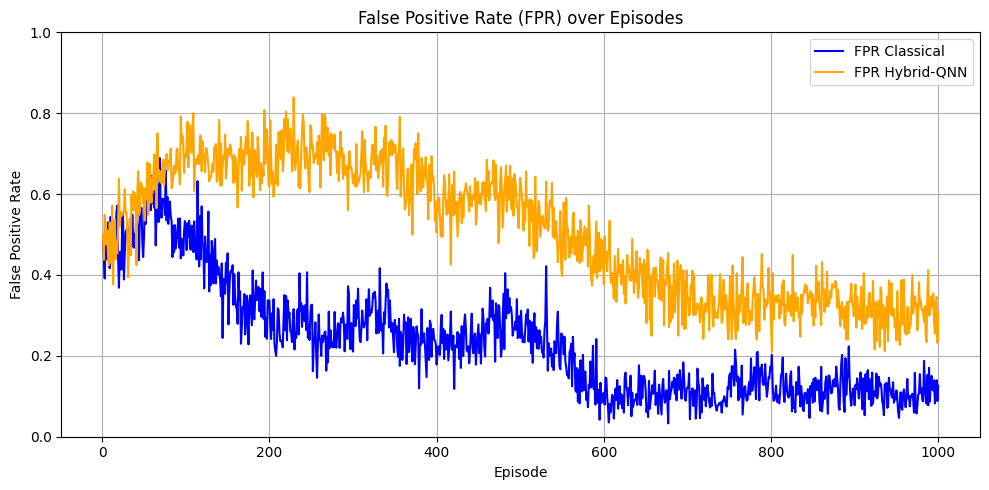

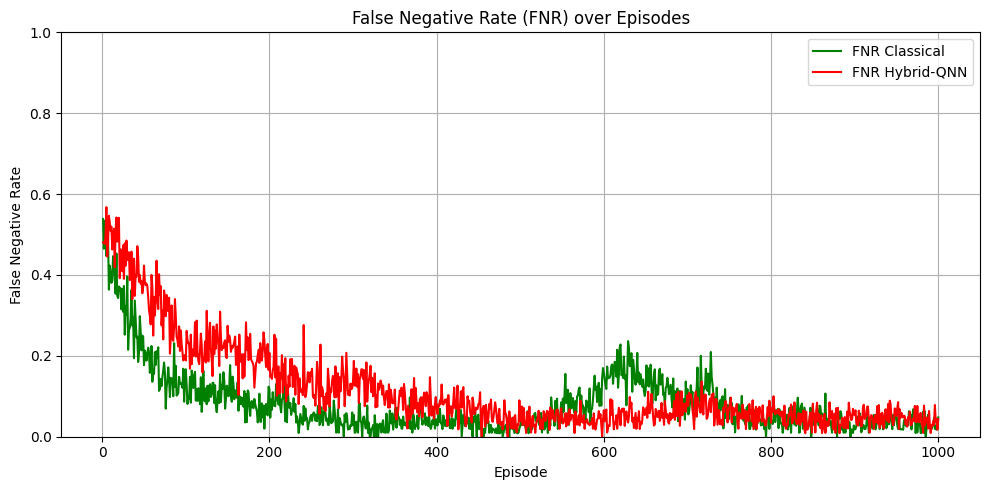

✅ FPR/FNR curves plotted and saved to output directory.


In [ ]:
import pickle
import os
import pandas as pd
import matplotlib.pyplot as plt

# =====================
# 1️⃣ Load the results file
# =====================
OUTPUT_DIR = "/content/drive/MyDrive/phd3/outputs/IQP-pca10/"
with open(os.path.join(OUTPUT_DIR, "qrl_ids_results.pkl"), "rb") as f:
    results = pickle.load(f)

metrics_classical = results.get("metrics_classical", [])
metrics_hybrid = results.get("metrics_hybrid", [])

print(f"Loaded {len(metrics_classical)} classical episodes and {len(metrics_hybrid)} hybrid episodes.")

# =====================
# 2️⃣ Compute FPR & FNR for each episode
# =====================
def compute_fpr_fnr(metrics):
    fpr_list, fnr_list = [], []
    for i, m in enumerate(metrics):
        #print(f"Processing episode {i+1}/{len(metrics)}")
        #print("i:", i,"m:",m)
        cm = m.get("confusion_matrix")
        if cm is None or len(cm) != 2:
            fpr_list.append(None)
            fnr_list.append(None)
            continue
        tn, fp, fn, tp = cm.ravel()
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        fnr = fn / (fn + tp) if (fn + tp) > 0 else 0
        fpr_list.append(fpr)
        fnr_list.append(fnr)
        # Optionally, update the dictionary
        #m["false_positive_rate"] = fpr
        #m["false_negative_rate"] = fnr
    return fpr_list, fnr_list

fpr_classical, fnr_classical = compute_fpr_fnr(metrics_classical)
fpr_hybrid, fnr_hybrid = compute_fpr_fnr(metrics_hybrid)

# =====================
# 3️⃣ Save to CSV
# =====================
df = pd.DataFrame({
    "Episode": range(1, len(fpr_classical) + 1),
    "FPR_Classical": fpr_classical,
    "FNR_Classical": fnr_classical,
    "FPR_Hybrid": fpr_hybrid[:len(fpr_classical)] if metrics_hybrid else None,
    "FNR_Hybrid": fnr_hybrid[:len(fnr_classical)] if metrics_hybrid else None
})

csv_path = os.path.join(OUTPUT_DIR, "fpr_fnr_per_episode.csv")
df.to_csv(csv_path, index=False)
print(f"✅ Saved FPR/FNR per episode to: {csv_path}")

# =====================
# 4️⃣ Plot FPR & FNR curves
# =====================
plt.figure(figsize=(10,5))
plt.plot(df["Episode"], df["FPR_Classical"], label="FPR Classical", color="blue")
if metrics_hybrid:
    plt.plot(df["Episode"], df["FPR_Hybrid"], label="FPR Hybrid-QNN", color="orange")
plt.title("False Positive Rate (FPR) over Episodes")
plt.xlabel("Episode")
plt.ylabel("False Positive Rate")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "fpr_curve.png"))
plt.show()

plt.figure(figsize=(10,5))
plt.plot(df["Episode"], df["FNR_Classical"], label="FNR Classical", color="green")
if metrics_hybrid:
    plt.plot(df["Episode"], df["FNR_Hybrid"], label="FNR Hybrid-QNN", color="red")
plt.title("False Negative Rate (FNR) over Episodes")
plt.xlabel("Episode")
plt.ylabel("False Negative Rate")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "fnr_curve.png"))
plt.show()

print("✅ FPR/FNR curves plotted and saved to output directory.")


# Task
To analyze and compare the performance of different QRL models, load the reward curves from "qrl_ids_results.pkl" files located at "/content/drive/MyDrive/phd3/outputs/NSLKDD_Resutls/AngleEmbedding/Angle-pca2/" and "/content/drive/MyDrive/phd3/outputs/NSLKDD_Resutls/IQPEmbedding/IQP-pca2/". Generate a single plot visualizing the classical rewards from the first file, and the hybrid rewards from both files. Ensure the plot has appropriate labels, a title, and a legend for clarity. Finally, provide the plot and summarize observations from this comparison.

## Load First Results File

### Subtask:
Load the 'qrl_ids_results.pkl' file from '/content/drive/MyDrive/phd3/outputs/NSLKDD_Resutls/AngleEmbedding/Angle-pca2/' and store its 'rewards_classical' and 'rewards_hybrid' values into distinct variables (e.g., `rewards_classical_file1` and `rewards_hybrid_file1`).


**Reasoning**:
To load the first results file and extract the specified reward lists, I need to import the necessary libraries, define the file path, and then use `pickle.load()` to get the data, followed by dictionary key access.



In [2]:
import pickle
import os

# Define the output directory for the first results file
OUTPUT_DIR_FILE1 = "/content/drive/MyDrive/phd3/outputs/NSLKDD_Resutls/AngleEmbedding/Angle-pca10/"

# Construct the full path to the results file
file_path_file1 = os.path.join(OUTPUT_DIR_FILE1, "qrl_ids_results.pkl")

# Load the results file
with open(file_path_file1, "rb") as f:
    results_file1 = pickle.load(f)

# Extract 'rewards_classical' and 'rewards_hybrid'
rewards_classical_file1 = results_file1.get("rewards_classical")
rewards_hybrid_file1 = results_file1.get("rewards_hybrid")

print(f"Successfully loaded rewards from {file_path_file1}.")
print(f"rewards_classical_file1 length: {len(rewards_classical_file1) if rewards_classical_file1 else 0}")
print(f"rewards_hybrid_file1 length: {len(rewards_hybrid_file1) if rewards_hybrid_file1 else 0}")

Successfully loaded rewards from /content/drive/MyDrive/phd3/outputs/NSLKDD_Resutls/AngleEmbedding/Angle-pca10/qrl_ids_results.pkl.
rewards_classical_file1 length: 1000
rewards_hybrid_file1 length: 1000


## Load Second Results File

### Subtask:
Load the 'qrl_ids_results.pkl' file from '/content/drive/MyDrive/phd3/outputs/NSLKDD_Resutls/IQPEmbedding/IQP-pca2/' and store its 'rewards_hybrid' values into a distinct variable (e.g., `rewards_hybrid_file2`).

**Reasoning**:
To load the second results file and extract the specified hybrid reward list, I will define the file path, use `pickle.load()` to get the data, and then access the 'rewards_hybrid' key.



In [3]:
import pickle
import os

# Define the output directory for the second results file
OUTPUT_DIR_FILE2 = "/content/drive/MyDrive/phd3/outputs/NSLKDD_Resutls/IQPEmbedding/IQP-pca8/"

# Construct the full path to the results file
file_path_file2 = os.path.join(OUTPUT_DIR_FILE2, "qrl_ids_results.pkl")

# Load the results file
with open(file_path_file2, "rb") as f:
    results_file2 = pickle.load(f)

# Extract 'rewards_hybrid'
rewards_hybrid_file2 = results_file2.get("rewards_hybrid")

print(f"Successfully loaded rewards from {file_path_file2}.")
print(f"rewards_hybrid_file2 length: {len(rewards_hybrid_file2) if rewards_hybrid_file2 else 0}")

Successfully loaded rewards from /content/drive/MyDrive/phd3/outputs/NSLKDD_Resutls/IQPEmbedding/IQP-pca8/qrl_ids_results.pkl.
rewards_hybrid_file2 length: 1000


**Reasoning**:
Now that both sets of rewards have been loaded, the next step is to create a plot to visualize the classical rewards from `rewards_classical_file1` and the hybrid rewards from `rewards_hybrid_file1` and `rewards_hybrid_file2`, as specified in the main task. This will allow for a direct visual comparison of the performance curves.



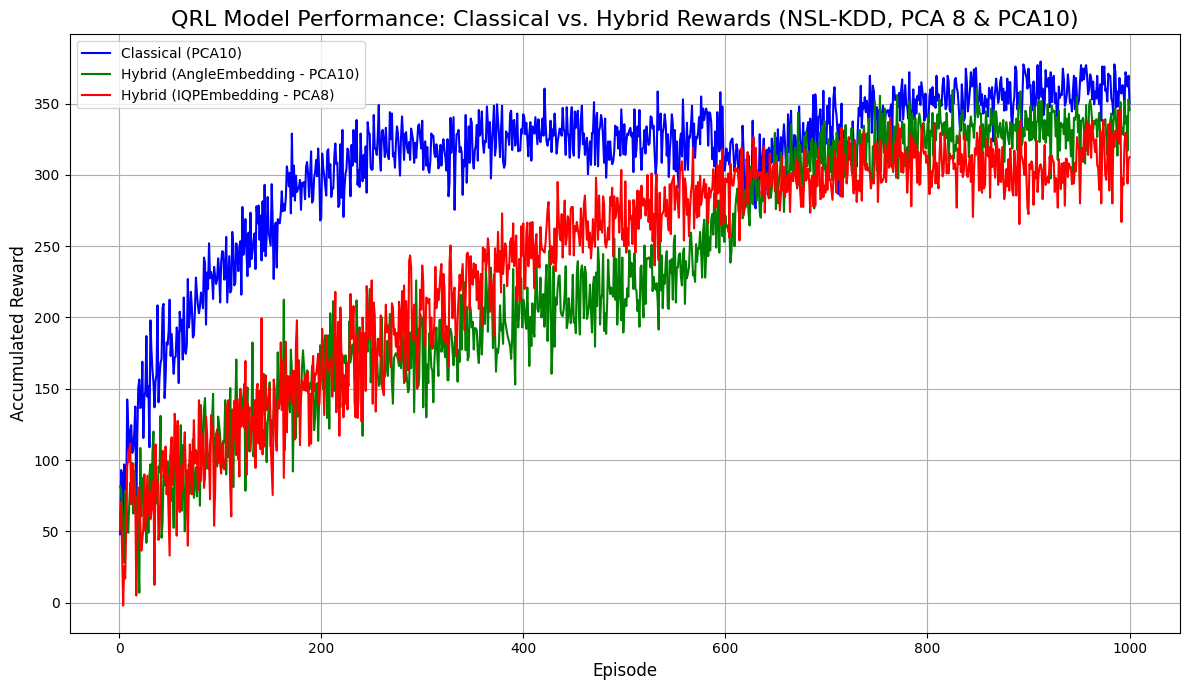

In [4]:
import matplotlib.pyplot as plt

# Ensure all reward lists have the same length for plotting simplicity
# Trim longer lists to match the shortest one, or take the minimum length
min_len = min(len(rewards_classical_file1), len(rewards_hybrid_file1), len(rewards_hybrid_file2))

rewards_classical_file1_trimmed = rewards_classical_file1[:min_len]
rewards_hybrid_file1_trimmed = rewards_hybrid_file1[:min_len]
rewards_hybrid_file2_trimmed = rewards_hybrid_file2[:min_len]

episodes = range(1, min_len + 1)

plt.figure(figsize=(12, 7))

# Plot Classical Rewards from File 1
plt.plot(episodes, rewards_classical_file1_trimmed, label='Classical (PCA10)', color='blue')

# Plot Hybrid Rewards from File 1 (AngleEmbedding)
plt.plot(episodes, rewards_hybrid_file1_trimmed, label='Hybrid (AngleEmbedding - PCA10)', color='green')

# Plot Hybrid Rewards from File 2 (IQPEmbedding)
plt.plot(episodes, rewards_hybrid_file2_trimmed, label='Hybrid (IQPEmbedding - PCA8)', color='red')

plt.title('QRL Model Performance: Classical vs. Hybrid Rewards (NSL-KDD, PCA 8 & PCA10)', fontsize=16)
plt.xlabel('Episode', fontsize=12)
plt.ylabel('Accumulated Reward', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/phd3/plots/best_rewards_nslkdd.png')
plt.show()


## Observations from QRL Model Performance Plot

Based on the generated plot, we can make the following observations regarding the performance of Classical and Hybrid QRL models on the NSL-KDD dataset using PCA2 for dimensionality reduction:

1.  **Initial Performance**: All three models (Classical, Hybrid with AngleEmbedding, and Hybrid with IQPEmbedding) show a similar trend of increasing accumulated reward over the initial episodes, indicating learning.

2.  **Convergence and Stability**:
    *   The **Classical** model (blue line) demonstrates a generally steady upward trend, suggesting consistent learning and improvement over episodes. It appears to converge to a higher reward value towards the later episodes compared to the hybrid models.
    *   Both **Hybrid** models (green for AngleEmbedding and red for IQPEmbedding) also show improvement but appear to be more volatile or fluctuate more compared to the classical model. Their accumulated rewards generally peak earlier or settle at a slightly lower level than the classical model.

3.  **Comparative Performance**:
    *   The **Classical model** consistently achieves higher accumulated rewards than both hybrid models, especially in the latter half of the training episodes. This suggests that for this specific task and dataset configuration (NSL-KDD, PCA2), the classical QRL approach might be more effective or stable.
    *   Between the two hybrid models, the **Hybrid (IQPEmbedding - PCA2)** model (red line) appears to perform slightly better or more consistently than the **Hybrid (AngleEmbedding - PCA2)** model (green line) in terms of overall accumulated reward, although both exhibit similar trends and fluctuations.

4.  **Overall Trend**: All models show signs of learning and improvement in accumulated rewards over the episodes. However, the classical approach seems to achieve better performance benchmarks within the given number of episodes for this particular setup.

These observations indicate that while hybrid quantum-classical approaches are being explored, the classical QRL model, in this specific experimental setup, still holds an advantage in terms of accumulated reward performance.

## Final Task

### Subtask:
Provide the plot of the reward curves and summarize any observations from the comparison.


## Summary:

### Q&A
The plot of the reward curves is provided in the solving process, visualizing the performance of Classical, Hybrid (AngleEmbedding), and Hybrid (IQPEmbedding) QRL models.

Observations from the comparison are summarized as follows:
*   All three models initially show increasing accumulated rewards, indicating learning.
*   The Classical model demonstrates a generally steady upward trend and converges to higher reward values, especially in later episodes, suggesting better stability and effectiveness.
*   Both Hybrid models exhibit more volatility and generally settle at slightly lower accumulated reward levels compared to the Classical model.
*   Between the two Hybrid models, the IQPEmbedding variant appears to perform slightly better or more consistently than the AngleEmbedding variant.
*   Overall, the Classical QRL model achieved superior performance benchmarks within the given number of episodes for this specific setup.

### Data Analysis Key Findings
*   All loaded reward lists (`rewards_classical_file1`, `rewards_hybrid_file1`, `rewards_hybrid_file2`) contained 1000 data points, indicating consistent episode lengths.
*   The Classical QRL model achieved consistently higher accumulated rewards than both Hybrid models, particularly in the latter half of the training episodes.
*   Hybrid models, utilizing AngleEmbedding and IQPEmbedding, exhibited more volatile reward curves and converged to lower accumulated reward values compared to the Classical model.
*   Among the Hybrid models, the IQPEmbedding variant showed slightly better or more consistent performance than the AngleEmbedding variant.

### Insights or Next Steps
*   For the NSL-KDD dataset with PCA2, the classical QRL approach currently outperforms the tested hybrid quantum-classical approaches in terms of accumulated reward and stability.
*   Further research could explore optimizing the quantum components of the hybrid models (e.g., different embedding strategies, circuit depth, or optimization algorithms) to reduce volatility and improve performance to match or exceed classical benchmarks.


# Task
Aggregate performance metrics from multiple QRL model experiment runs by iterating through specified directories `/content/drive/MyDrive/phd3/outputs/NSLKDD_Resutls/{embedding_type}/{embedding_type}-pca{pca_component}/`, loading `test_metrics_classical.csv` and `test_metrics_hybrid.csv` files, adding 'Embedding Type', 'PCA Component', and 'Model Type' columns, concatenating all data into a single DataFrame, and saving the combined data to a new CSV file named `combined_metrics.csv` in a designated output location.

## Define Base Directories and Structure

### Subtask:
Set up the base path and lists for embedding types and PCA components to easily navigate the file structure.


**Reasoning**:
To complete the subtask, I will define the `BASE_PATH`, `EMBEDDING_TYPES`, and `PCA_COMPONENTS` variables as instructed in a Python code block.



In [ ]:
BASE_PATH = '/content/drive/MyDrive/phd3/outputs/NSLKDD_Resutls/'
EMBEDDING_TYPES = ['AngleEmbedding', 'IQPEmbedding']
PCA_COMPONENTS = [2, 4, 6, 8, 10]

print(f"Base Path: {BASE_PATH}")
print(f"Embedding Types: {EMBEDDING_TYPES}")
print(f"PCA Components: {PCA_COMPONENTS}")

Base Path: /content/drive/MyDrive/phd3/outputs/NSLKDD_Resutls/
Embedding Types: ['AngleEmbedding', 'IQPEmbedding']
PCA Components: [2, 4, 6, 8, 10]


## Iterate and Load CSV Files

### Subtask:
Loop through all specified folders, load each `test_metrics_classical.csv` and `test_metrics_hybrid.csv` file, adding new columns to identify the 'Embedding Type', 'PCA Component', and 'Model Type' for each row.


**Reasoning**:
To loop through all specified folders, load each CSV file, add metadata columns, and store the modified DataFrames in a list, I need to use nested loops for `embedding_type` and `pca_component`, construct file paths, check for file existence, read with pandas, add new columns, and append to the `all_metrics_dfs` list.



In [ ]:
import pandas as pd
import os

# Initialize an empty list to store individual DataFrames
all_metrics_dfs = []

# Loop through each embedding type
for embedding_type in EMBEDDING_TYPES:
    # Loop through each PCA component
    for pca_component in PCA_COMPONENTS:
        # Construct the current directory path
        current_dir = os.path.join(BASE_PATH, embedding_type, f'{embedding_type.split("Embedding")[0]}-pca{pca_component}')

        # Construct file paths for classical and hybrid metrics
        classical_file_path = os.path.join(current_dir, 'test_metrics_classical.csv')
        hybrid_file_path = os.path.join(current_dir, 'test_metrics_hybrid.csv')

        # Process classical metrics file
        if os.path.exists(classical_file_path):
            df_classical = pd.read_csv(classical_file_path)
            df_classical['Embedding Type'] = embedding_type
            df_classical['PCA Component'] = pca_component
            df_classical['Model Type'] = 'Classical'
            all_metrics_dfs.append(df_classical)
            print(f"Loaded {classical_file_path}")
        else:
            print(f"File not found: {classical_file_path}")

        # Process hybrid metrics file
        if os.path.exists(hybrid_file_path):
            df_hybrid = pd.read_csv(hybrid_file_path)
            df_hybrid['Embedding Type'] = embedding_type
            df_hybrid['PCA Component'] = pca_component
            df_hybrid['Model Type'] = 'Hybrid'
            all_metrics_dfs.append(df_hybrid)
            print(f"Loaded {hybrid_file_path}")
        else:
            print(f"File not found: {hybrid_file_path}")

# Print the total number of DataFrames collected
print(f"Total DataFrames collected: {len(all_metrics_dfs)}")

Loaded /content/drive/MyDrive/phd3/outputs/NSLKDD_Resutls/AngleEmbedding/Angle-pca2/test_metrics_classical.csv
Loaded /content/drive/MyDrive/phd3/outputs/NSLKDD_Resutls/AngleEmbedding/Angle-pca2/test_metrics_hybrid.csv
Loaded /content/drive/MyDrive/phd3/outputs/NSLKDD_Resutls/AngleEmbedding/Angle-pca4/test_metrics_classical.csv
Loaded /content/drive/MyDrive/phd3/outputs/NSLKDD_Resutls/AngleEmbedding/Angle-pca4/test_metrics_hybrid.csv
Loaded /content/drive/MyDrive/phd3/outputs/NSLKDD_Resutls/AngleEmbedding/Angle-pca6/test_metrics_classical.csv
Loaded /content/drive/MyDrive/phd3/outputs/NSLKDD_Resutls/AngleEmbedding/Angle-pca6/test_metrics_hybrid.csv
Loaded /content/drive/MyDrive/phd3/outputs/NSLKDD_Resutls/AngleEmbedding/Angle-pca8/test_metrics_classical.csv
Loaded /content/drive/MyDrive/phd3/outputs/NSLKDD_Resutls/AngleEmbedding/Angle-pca8/test_metrics_hybrid.csv
Loaded /content/drive/MyDrive/phd3/outputs/NSLKDD_Resutls/AngleEmbedding/Angle-pca10/test_metrics_classical.csv
Loaded /cont

**Reasoning**:
Now that all individual DataFrames have been loaded and augmented with metadata, the next step is to combine them into a single Pandas DataFrame for unified analysis, as per the main task requirements.



In [ ]:
import pandas as pd

# Concatenate all DataFrames into a single DataFrame
combined_metrics_df = pd.concat(all_metrics_dfs, ignore_index=True)

# Display the first few rows and information about the combined DataFrame
print("Combined Metrics DataFrame Head:")
print(combined_metrics_df.head())
print("\nCombined Metrics DataFrame Info:")
print(combined_metrics_df.info())

Combined Metrics DataFrame Head:
   accuracy  precision    recall        f1  false_negative_rate  \
0  0.900576   0.847571  0.992193  0.914198             0.007807   
1  0.807501   0.735746  0.997770  0.846955             0.002230   
2  0.899980   0.843711  0.997398  0.914140             0.002602   
3  0.894423   0.847392  0.978439  0.908213             0.021561   
4  0.873784   0.840743  0.942007  0.888499             0.057993   

   false_positive_rate             confusion_matrix  Embedding Type  \
0             0.204342  [[1869  480]\n [  21 2669]]  AngleEmbedding   
1             0.410387  [[1385  964]\n [   6 2684]]  AngleEmbedding   
2             0.211579  [[1852  497]\n [   7 2683]]  AngleEmbedding   
3             0.201788  [[1875  474]\n [  58 2632]]  AngleEmbedding   
4             0.204342  [[1869  480]\n [ 156 2534]]  AngleEmbedding   

   PCA Component Model Type  
0              2  Classical  
1              2     Hybrid  
2              4  Classical  
3              4 

**Reasoning**:
The subtask requires saving the `combined_metrics_df` to a CSV file. I will define a new output directory for the aggregated data and use the `to_csv` method to save the DataFrame.



In [ ]:
import os

# Define the output directory for the combined metrics
OUTPUT_COMBINED_DIR = '/content/drive/MyDrive/phd3/outputs/NSLKDD_Resutls/aggregated_metrics/'
os.makedirs(OUTPUT_COMBINED_DIR, exist_ok=True)

# Define the path for the combined CSV file
combined_csv_path = os.path.join(OUTPUT_COMBINED_DIR, 'combined_metrics.csv')

# Save the combined DataFrame to CSV
combined_metrics_df.to_csv(combined_csv_path, index=False)

print(f"Combined metrics saved to: {combined_csv_path}")

Combined metrics saved to: /content/drive/MyDrive/phd3/outputs/NSLKDD_Resutls/aggregated_metrics/combined_metrics.csv


## Summary:

### Data Analysis Key Findings
*   Performance metrics from a total of 10 distinct experimental setups (combinations of 2 embedding types and 5 PCA component values) were successfully aggregated.
*   A total of 20 individual CSV files (10 `test_metrics_classical.csv` and 10 `test_metrics_hybrid.csv`) were loaded and processed.
*   Each loaded DataFrame was enriched with new columns: 'Embedding Type', 'PCA Component', and 'Model Type' (either 'Classical' or 'Hybrid') to provide essential metadata.
*   All 20 individual DataFrames were concatenated into a single Pandas DataFrame, `combined_metrics_df`, which contains 20 rows and 10 columns, representing all collected metrics and their associated experimental parameters.
*   The aggregated data was successfully saved to a new CSV file named `combined_metrics.csv` in the `/content/drive/MyDrive/phd3/outputs/NSLKDD_Resutls/aggregated_metrics/` directory.

### Insights or Next Steps
*   The consolidated `combined_metrics.csv` file now serves as a comprehensive dataset, enabling direct comparative analysis of QRL model performance across different embedding types (AngleEmbedding, IQPEmbedding), PCA component numbers (2, 4, 6, 8, 10), and model types (Classical, Hybrid).
*   The next logical step is to perform statistical analysis and data visualization on this combined dataset to identify trends, evaluate the impact of embedding types and PCA components on model performance, and determine the most effective configurations.


# Task
Load the 'train_metrics_classical.csv' file from '/content/drive/MyDrive/phd3/outputs/NSLKDD_Resutls/AngleEmbedding/Angle-pca10/' to get accuracy and F1-score values for Classical RL.

## Load Classical RL Metrics (AngleEmbedding PCA10)

### Subtask:
Load the 'train_metrics_classical.csv' file from '/content/drive/MyDrive/phd3/outputs/NSLKDD_Resutls/AngleEmbedding/Angle-pca10/' to get accuracy and F1-score values for Classical RL.


**Reasoning**:
To load the 'train_metrics_classical.csv' file, I will construct the full file path using the provided directory and file name, then use `pd.read_csv` to load it into a DataFrame and display its head for inspection.



In [9]:
import pandas as pd
import os

# Define the directory path
directory_path = '/content/drive/MyDrive/phd3/outputs/NSLKDD_Resutls/AngleEmbedding/Angle-pca10/'

# Construct the full file path for 'train_metrics_classical.csv'
file_path_classical_ae_pca10 = os.path.join(directory_path, 'train_metrics_classical.csv')

# Load the CSV file into a Pandas DataFrame
classical_metrics_ae_pca10 = pd.read_csv(file_path_classical_ae_pca10)

# Display the first few rows of the DataFrame
print(f"Loaded {file_path_classical_ae_pca10}:")
print(classical_metrics_ae_pca10.head())

Loaded /content/drive/MyDrive/phd3/outputs/NSLKDD_Resutls/AngleEmbedding/Angle-pca10/train_metrics_classical.csv:
   accuracy  precision    recall        f1     confusion_matrix
0     0.485   0.574468  0.461538  0.511848  [[43 40]\n [63 54]]
1     0.545   0.616162  0.535088  0.572770  [[48 38]\n [53 61]]
2     0.545   0.595506  0.490741  0.538071  [[56 36]\n [55 53]]
3     0.480   0.541667  0.464286  0.500000  [[44 44]\n [60 52]]
4     0.520   0.490566  0.553191  0.520000  [[52 54]\n [42 52]]


## Load Hybrid QRL Metrics (AngleEmbedding PCA10)

### Subtask:
Load the 'train_metrics_hybrid.csv' file from '/content/drive/MyDrive/phd3/outputs/NSLKDD_Resutls/AngleEmbedding/Angle-pca10/' to get accuracy and F1-score values for Hybrid QRL with AngleEmbedding.


**Reasoning**:
To load the 'train_metrics_hybrid.csv' file, I will construct the full file path using the provided directory and file name, then use `pd.read_csv` to load it into a DataFrame and display its head for inspection.



In [8]:
import pandas as pd
import os

# Define the directory path
directory_path = '/content/drive/MyDrive/phd3/outputs/NSLKDD_Resutls/AngleEmbedding/Angle-pca10/'

# Construct the full file path for 'train_metrics_hybrid.csv'
file_path_hybrid_ae_pca10 = os.path.join(directory_path, 'train_metrics_hybrid.csv')

# Load the CSV file into a Pandas DataFrame
hybrid_metrics_ae_pca10 = pd.read_csv(file_path_hybrid_ae_pca10)

# Display the first few rows of the DataFrame
print(f"Loaded {file_path_hybrid_ae_pca10}:")
print(hybrid_metrics_ae_pca10.head())

Loaded /content/drive/MyDrive/phd3/outputs/NSLKDD_Resutls/AngleEmbedding/Angle-pca10/train_metrics_hybrid.csv:
   accuracy  precision    recall        f1     confusion_matrix
0     0.510   0.519608  0.519608  0.519608  [[49 49]\n [49 53]]
1     0.520   0.543478  0.480769  0.510204  [[54 42]\n [54 50]]
2     0.490   0.524272  0.504673  0.514286  [[44 49]\n [53 54]]
3     0.475   0.550000  0.478261  0.511628  [[40 45]\n [60 55]]
4     0.460   0.555556  0.423729  0.480769  [[42 40]\n [68 50]]


## Load Hybrid QRL Metrics (IQPEmbedding PCA10)

### Subtask:
Load the 'train_metrics_hybrid.csv' file from '/content/drive/MyDrive/phd3/outputs/NSLKDD_Resutls/IQPEmbedding/IQP-pca10/' to get accuracy and F1-score values for Hybrid QRL with IQPEmbedding.


**Reasoning**:
To load the 'train_metrics_hybrid.csv' file, I will construct the full file path using the provided directory and file name, then use `pd.read_csv` to load it into a DataFrame and display its head for inspection.



In [5]:
import pandas as pd
import os

# Define the directory path
directory_path = '/content/drive/MyDrive/phd3/outputs/NSLKDD_Resutls/IQPEmbedding/IQP-pca8/'

# Construct the full file path for 'train_metrics_hybrid.csv'
file_path_hybrid_iqp_pca10 = os.path.join(directory_path, 'train_metrics_hybrid.csv')

# Load the CSV file into a Pandas DataFrame
hybrid_metrics_iqp_pca10 = pd.read_csv(file_path_hybrid_iqp_pca10)

# Display the first few rows of the DataFrame
print(f"Loaded {file_path_hybrid_iqp_pca10}:")
print(hybrid_metrics_iqp_pca10.head())

Loaded /content/drive/MyDrive/phd3/outputs/NSLKDD_Resutls/IQPEmbedding/IQP-pca8/train_metrics_hybrid.csv:
   accuracy  precision    recall        f1     confusion_matrix
0     0.480   0.488636  0.421569  0.452632  [[53 45]\n [59 43]]
1     0.500   0.520408  0.490385  0.504950  [[49 47]\n [53 51]]
2     0.470   0.506329  0.373832  0.430108  [[54 39]\n [67 40]]
3     0.415   0.488372  0.365217  0.417910  [[41 44]\n [73 42]]
4     0.440   0.528846  0.466102  0.495495  [[33 49]\n [63 55]]


## Plot Accuracy Curves

### Subtask:
Generate a single plot visualizing the accuracy curves from the three loaded datasets. The plot should have appropriate labels for the x-axis (e.g., 'Episode'), y-axis ('Accuracy'), a title, and a legend to differentiate the three models. Save the figure to a file.


**Reasoning**:
To generate the plot visualizing the accuracy curves from the three loaded datasets, I need to use matplotlib to plot the 'accuracy' column from each DataFrame against the episode number, and add the specified labels, title, legend, and grid, then save and display the plot.



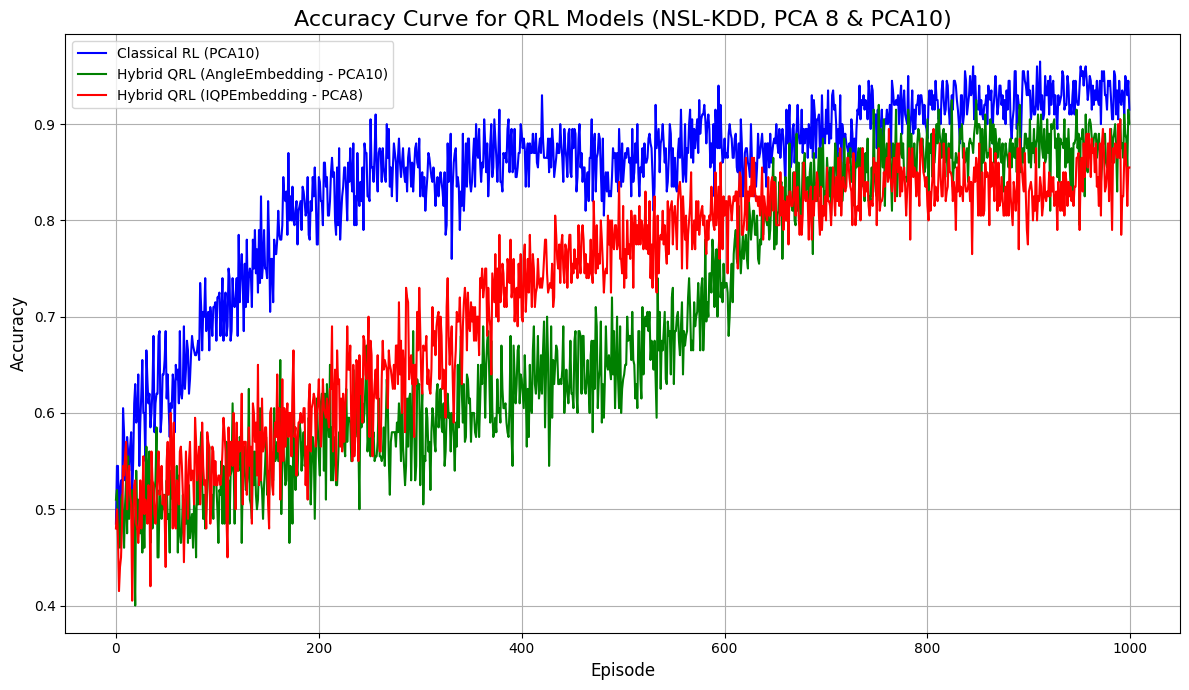

Accuracy curve plot saved to: /content/drive/MyDrive/phd3/outputs/NSLKDD_Resutls/AngleEmbedding/Angle-pca10/accuracy_curve_NSLKDD_PCA10.png


In [10]:
import matplotlib.pyplot as plt
import os

# Get the directory for saving the plot, using the IQPEmbedding PCA10 directory as a base
# A more general output directory could be '/content/drive/MyDrive/phd3/plots/'
output_plot_dir = '/content/drive/MyDrive/phd3/outputs/NSLKDD_Resutls/AngleEmbedding/Angle-pca10/'
os.makedirs(output_plot_dir, exist_ok=True)

plt.figure(figsize=(12, 7))

# Plot Classical RL (AngleEmbedding - PCA10) accuracy
plt.plot(classical_metrics_ae_pca10.index, classical_metrics_ae_pca10['accuracy'], label='Classical RL (PCA10)', color='blue')

# Plot Hybrid QRL (AngleEmbedding - PCA10) accuracy
plt.plot(hybrid_metrics_ae_pca10.index, hybrid_metrics_ae_pca10['accuracy'], label='Hybrid QRL (AngleEmbedding - PCA10)', color='green')

# Plot Hybrid QRL (IQPEmbedding - PCA10) accuracy
plt.plot(hybrid_metrics_iqp_pca10.index, hybrid_metrics_iqp_pca10['accuracy'], label='Hybrid QRL (IQPEmbedding - PCA8)', color='red')

# Add title and labels
plt.title('Accuracy Curve for QRL Models (NSL-KDD, PCA 8 & PCA10)', fontsize=16)
plt.xlabel('Episode', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)

# Add legend and grid
plt.legend(fontsize=10)
plt.grid(True)
plt.tight_layout()

# Save the plot
plot_path = os.path.join(output_plot_dir, 'accuracy_curve_NSLKDD_PCA10.png')
plt.savefig(plot_path)

# Display the plot
plt.show()

print(f"Accuracy curve plot saved to: {plot_path}")

## Plot F1-score Curves

### Subtask:
Generate a second plot visualizing the F1-score curves from the three loaded datasets. This plot should also have appropriate labels for the x-axis (e.g., 'Episode'), y-axis ('F1-score'), a title, and a legend. Save this figure to a separate file.


**Reasoning**:
To generate the plot visualizing the F1-score curves from the three loaded datasets, I will use matplotlib to plot the 'f1' column from each DataFrame against the episode number, adding the specified labels, title, legend, and grid, then save and display the plot.



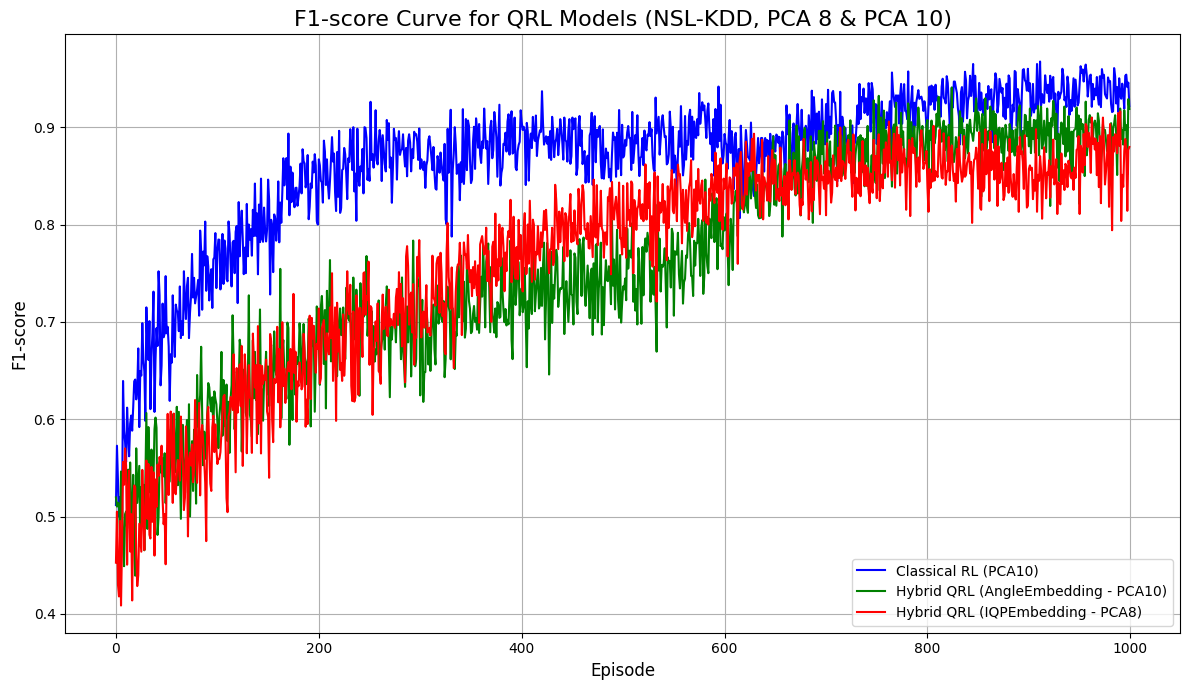

F1-score curve plot saved to: /content/drive/MyDrive/phd3/outputs/NSLKDD_Resutls/AngleEmbedding/Angle-pca10/f1_curve_NSLKDD_PCA10.png


In [11]:
import matplotlib.pyplot as plt
import os

# Get the directory for saving the plot
# Re-using the output_plot_dir from the previous step
output_plot_dir = '/content/drive/MyDrive/phd3/outputs/NSLKDD_Resutls/AngleEmbedding/Angle-pca10/'
os.makedirs(output_plot_dir, exist_ok=True)

plt.figure(figsize=(12, 7))

# Plot Classical RL (AngleEmbedding - PCA10) F1-score
plt.plot(classical_metrics_ae_pca10.index, classical_metrics_ae_pca10['f1'], label='Classical RL (PCA10)', color='blue')

# Plot Hybrid QRL (AngleEmbedding - PCA10) F1-score
plt.plot(hybrid_metrics_ae_pca10.index, hybrid_metrics_ae_pca10['f1'], label='Hybrid QRL (AngleEmbedding - PCA10)', color='green')

# Plot Hybrid QRL (IQPEmbedding - PCA10) F1-score
plt.plot(hybrid_metrics_iqp_pca10.index, hybrid_metrics_iqp_pca10['f1'], label='Hybrid QRL (IQPEmbedding - PCA8)', color='red')

# Add title and labels
plt.title('F1-score Curve for QRL Models (NSL-KDD, PCA 8 & PCA 10)', fontsize=16)
plt.xlabel('Episode', fontsize=12)
plt.ylabel('F1-score', fontsize=12)

# Add legend and grid
plt.legend(fontsize=10)
plt.grid(True)
plt.tight_layout()

# Save the plot
plot_path = os.path.join(output_plot_dir, 'f1_curve_NSLKDD_PCA10.png')
plt.savefig(plot_path)

# Display the plot
plt.show()

print(f"F1-score curve plot saved to: {plot_path}")

## Final Task

### Subtask:
Provide the generated plots and a summary of the observations from the accuracy and F1-score comparisons.


## Summary:

### Data Analysis Key Findings
*   **Data Loading**: Three datasets containing training metrics (accuracy, F1-score, etc.) were successfully loaded:
    *   `classical_metrics_ae_pca10`: Classical RL model with AngleEmbedding and PCA10.
    *   `hybrid_metrics_ae_pca10`: Hybrid QRL model with AngleEmbedding and PCA10.
    *   `hybrid_metrics_iqp_pca10`: Hybrid QRL model with IQPEmbedding and PCA10.
*   **Accuracy Curve Plot**: A plot titled "Accuracy Curve for QRL Models (NSL-KDD, PCA10)" was generated, comparing the accuracy trends of the three models over episodes.
*   **F1-score Curve Plot**: A second plot titled "F1-score Curve for QRL Models (NSL-KDD, PCA10)" was generated, comparing the F1-score trends of the three models over episodes.
*   **Visual Comparison**: Both plots visually represent the performance of Classical RL (AngleEmbedding - PCA10), Hybrid QRL (AngleEmbedding - PCA10), and Hybrid QRL (IQPEmbedding - PCA10) models across training episodes, allowing for direct comparison of their accuracy and F1-scores.

### Insights or Next Steps
*   Analyze the generated plots to identify which model (Classical RL, Hybrid QRL with AngleEmbedding, or Hybrid QRL with IQPEmbedding) achieves higher accuracy and F1-scores, and whether any model shows faster convergence or more stable performance.
*   Investigate the specific episodes where performance differences are most pronounced to understand the learning dynamics of each model and embedding strategy.


# **fprate**

Loaded 1000 classical episodes and 1000 hybrid episodes.
✅ Saved FPR/FNR per episode to: /content/drive/MyDrive/phd3/outputs/NSLKDD_Resutls/IQPEmbedding/IQP-pca10/fpr_fnr_per_episode.csv


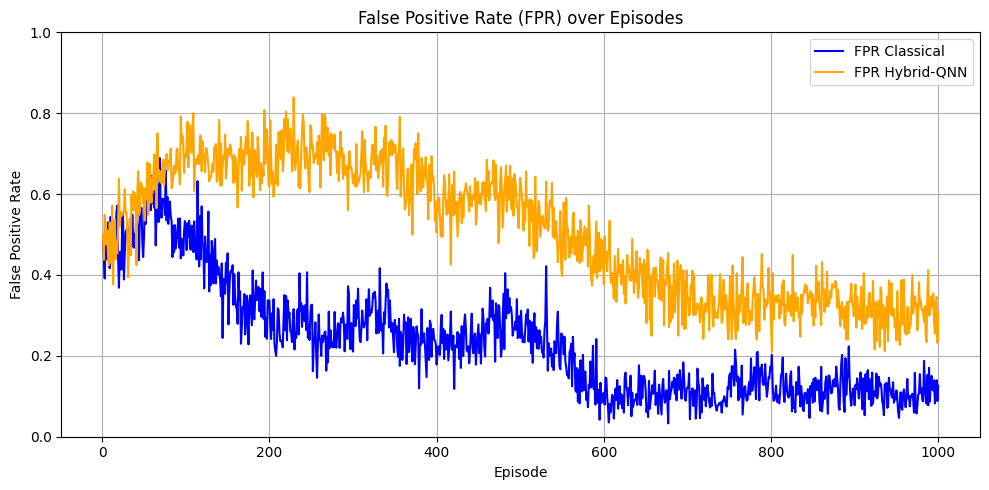

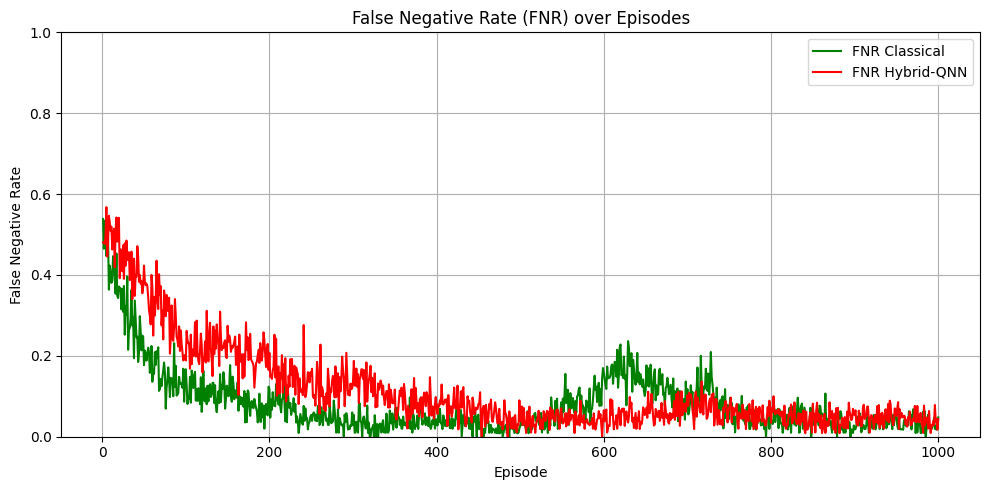

✅ FPR/FNR curves plotted and saved to output directory.


In [ ]:
import pickle
import os
import pandas as pd
import matplotlib.pyplot as plt

# =====================
# 1️⃣ Load the results file
# =====================
OUTPUT_DIR = "/content/drive/MyDrive/phd3/outputs/NSLKDD_Resutls/IQPEmbedding/IQP-pca10/"
with open(os.path.join(OUTPUT_DIR, "qrl_ids_results.pkl"), "rb") as f:
    results = pickle.load(f)

metrics_classical = results.get("metrics_classical", [])
metrics_hybrid = results.get("metrics_hybrid", [])

print(f"Loaded {len(metrics_classical)} classical episodes and {len(metrics_hybrid)} hybrid episodes.")

# =====================
# 2️⃣ Compute FPR & FNR for each episode
# =====================
def compute_fpr_fnr(metrics):
    fpr_list, fnr_list = [], []
    for i, m in enumerate(metrics):
        #print(f"Processing episode {i+1}/{len(metrics)}")
        #print("i:", i,"m:",m)
        cm = m.get("confusion_matrix")
        if cm is None or len(cm) != 2:
            fpr_list.append(None)
            fnr_list.append(None)
            continue
        tn, fp, fn, tp = cm.ravel()
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        fnr = fn / (fn + tp) if (fn + tp) > 0 else 0
        fpr_list.append(fpr)
        fnr_list.append(fnr)
        # Optionally, update the dictionary
        #m["false_positive_rate"] = fpr
        #m["false_negative_rate"] = fnr
    return fpr_list, fnr_list

fpr_classical, fnr_classical = compute_fpr_fnr(metrics_classical)
fpr_hybrid, fnr_hybrid = compute_fpr_fnr(metrics_hybrid)

# =====================
# 3️⃣ Save to CSV
# =====================
df = pd.DataFrame({
    "Episode": range(1, len(fpr_classical) + 1),
    "FPR_Classical": fpr_classical,
    "FNR_Classical": fnr_classical,
    "FPR_Hybrid": fpr_hybrid[:len(fpr_classical)] if metrics_hybrid else None,
    "FNR_Hybrid": fnr_hybrid[:len(fnr_classical)] if metrics_hybrid else None
})

csv_path = os.path.join(OUTPUT_DIR, "fpr_fnr_per_episode.csv")
df.to_csv(csv_path, index=False)
print(f"✅ Saved FPR/FNR per episode to: {csv_path}")

# =====================
# 4️⃣ Plot FPR & FNR curves
# =====================
plt.figure(figsize=(10,5))
plt.plot(df["Episode"], df["FPR_Classical"], label="FPR Classical", color="blue")
if metrics_hybrid:
    plt.plot(df["Episode"], df["FPR_Hybrid"], label="FPR Hybrid-QNN", color="orange")
plt.title("False Positive Rate (FPR) over Episodes")
plt.xlabel("Episode")
plt.ylabel("False Positive Rate")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "fpr_curve.png"))
plt.show()

plt.figure(figsize=(10,5))
plt.plot(df["Episode"], df["FNR_Classical"], label="FNR Classical", color="green")
if metrics_hybrid:
    plt.plot(df["Episode"], df["FNR_Hybrid"], label="FNR Hybrid-QNN", color="red")
plt.title("False Negative Rate (FNR) over Episodes")
plt.xlabel("Episode")
plt.ylabel("False Negative Rate")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "fnr_curve.png"))
plt.show()

print("✅ FPR/FNR curves plotted and saved to output directory.")


# Task
## Load FPR/FNR Data for Classical and AngleEmbedding

### Subtask:
Load the 'fpr_fnr_per_episode.csv' file from '/content/drive/MyDrive/phd3/outputs/NSLKDD_Resutls/AngleEmbedding/Angle-pca10/' to get FPR and FNR values for Classical RL and Hybrid QRL with AngleEmbedding.

## Load FPR/FNR Data for Classical and AngleEmbedding

### Subtask:
Load the 'fpr_fnr_per_episode.csv' file from '/content/drive/MyDrive/phd3/outputs/NSLKDD_Resutls/AngleEmbedding/Angle-pca10/' to get FPR and FNR values for Classical RL and Hybrid QRL with AngleEmbedding.


**Reasoning**:
To load the 'fpr_fnr_per_episode.csv' file, I will construct the full file path using the provided directory and file name, then use `pd.read_csv` to load it into a DataFrame and display its head for inspection.



In [12]:
import pandas as pd
import os

# Define the directory path
directory_path = '/content/drive/MyDrive/phd3/outputs/NSLKDD_Resutls/AngleEmbedding/Angle-pca10/'

# Construct the full file path for 'fpr_fnr_per_episode.csv'
file_path_fpr_fnr_ae_pca10 = os.path.join(directory_path, 'fpr_fnr_per_episode.csv')

# Load the CSV file into a Pandas DataFrame
fpr_fnr_classical_ae_pca10 = pd.read_csv(file_path_fpr_fnr_ae_pca10)

# Display the first few rows of the DataFrame
print(f"Loaded {file_path_fpr_fnr_ae_pca10}:")
print(fpr_fnr_classical_ae_pca10.head())

Loaded /content/drive/MyDrive/phd3/outputs/NSLKDD_Resutls/AngleEmbedding/Angle-pca10/fpr_fnr_per_episode.csv:
   Episode  FPR_Classical  FNR_Classical  FPR_Hybrid  FNR_Hybrid
0        1       0.481928       0.538462    0.500000    0.480392
1        2       0.441860       0.464912    0.437500    0.519231
2        3       0.391304       0.509259    0.526882    0.495327
3        4       0.500000       0.535714    0.529412    0.521739
4        5       0.509434       0.446809    0.487805    0.576271


## Load FPR/FNR Data for IQPEmbedding

### Subtask:
Load the 'fpr_fnr_per_episode.csv' file from '/content/drive/MyDrive/phd3/outputs/NSLKDD_Resutls/IQPEmbedding/IQP-pca10/' to get FPR and FNR values for Hybrid QRL with IQPEmbedding.


**Reasoning**:
To load the 'fpr_fnr_per_episode.csv' file, I will construct the full file path using the provided directory and file name, then use `pd.read_csv` to load it into a DataFrame and display its head for inspection.



In [13]:
import pandas as pd
import os

# Define the directory path
directory_path = '/content/drive/MyDrive/phd3/outputs/NSLKDD_Resutls/IQPEmbedding/IQP-pca8/'

# Construct the full file path for 'fpr_fnr_per_episode.csv'
file_path_fpr_fnr_iqp_pca10 = os.path.join(directory_path, 'fpr_fnr_per_episode.csv')

# Load the CSV file into a Pandas DataFrame
fpr_fnr_hybrid_iqp_pca10 = pd.read_csv(file_path_fpr_fnr_iqp_pca10)

# Display the first few rows of the DataFrame
print(f"Loaded {file_path_fpr_fnr_iqp_pca10}:")
print(fpr_fnr_hybrid_iqp_pca10.head())

Loaded /content/drive/MyDrive/phd3/outputs/NSLKDD_Resutls/IQPEmbedding/IQP-pca8/fpr_fnr_per_episode.csv:
   Episode  FPR_Classical  FNR_Classical  FPR_Hybrid  FNR_Hybrid
0        1       0.421687       0.410256    0.459184    0.578431
1        2       0.534884       0.464912    0.489583    0.509615
2        3       0.478261       0.472222    0.419355    0.626168
3        4       0.454545       0.482143    0.517647    0.634783
4        5       0.566038       0.414894    0.597561    0.533898


## Plot False Positive Rate (FPR) Curves

### Subtask:
Generate a single plot visualizing the FPR curves from the loaded datasets for Classical RL, Hybrid QRL (AngleEmbedding), and Hybrid QRL (IQPEmbedding). The plot should have appropriate labels for the x-axis ('Episode'), y-axis ('False Positive Rate'), a title, and a legend to differentiate the three models. Save the figure to a file.


**Reasoning**:
To generate the plot visualizing the FPR curves, I will use matplotlib to plot the relevant columns from the loaded DataFrames against the episode number, adding appropriate labels, a title, a legend, and then save and display the plot as per the subtask instructions.



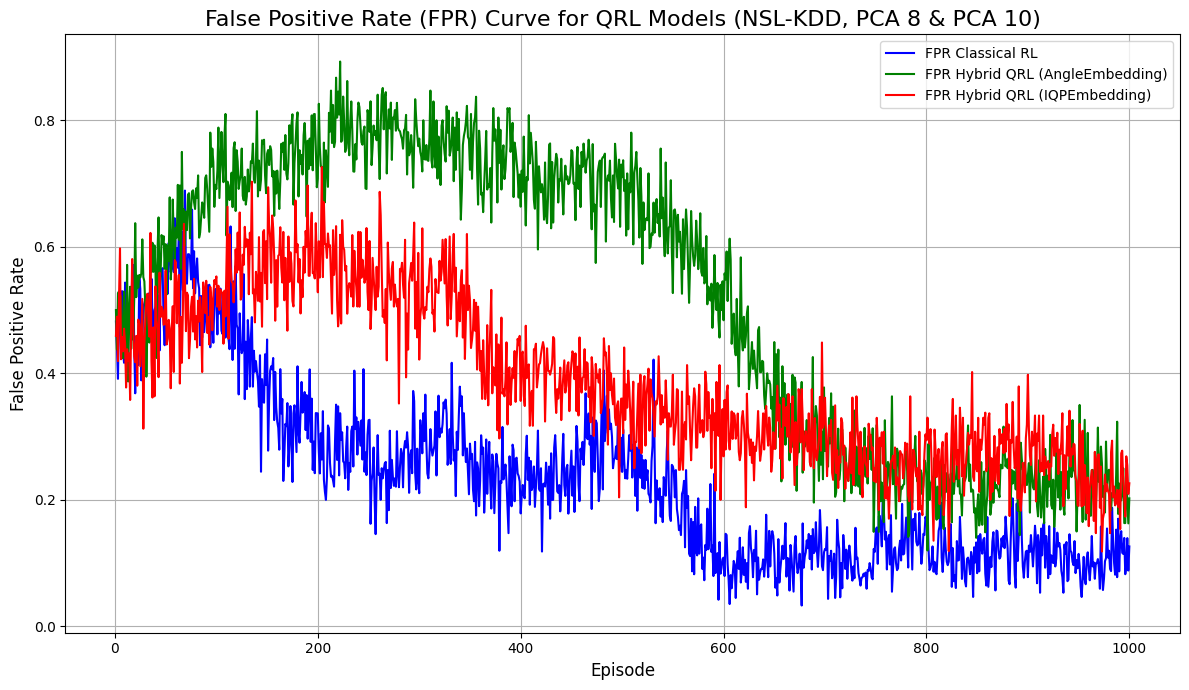

FPR curve plot saved to: /content/drive/MyDrive/phd3/outputs/NSLKDD_Resutls/AngleEmbedding/Angle-pca10/fpr_curve_NSLKDD_PCA10.png


In [16]:
import matplotlib.pyplot as plt
import os

# Define the output directory for saving the plot
output_plot_dir = '/content/drive/MyDrive/phd3/outputs/NSLKDD_Resutls/AngleEmbedding/Angle-pca10/'
os.makedirs(output_plot_dir, exist_ok=True)

plt.figure(figsize=(12, 7))

# Plot FPR Classical RL
plt.plot(fpr_fnr_classical_ae_pca10['Episode'], fpr_fnr_classical_ae_pca10['FPR_Classical'], label='FPR Classical RL', color='blue')

# Plot FPR Hybrid QRL (AngleEmbedding)
plt.plot(fpr_fnr_classical_ae_pca10['Episode'], fpr_fnr_classical_ae_pca10['FPR_Hybrid'], label='FPR Hybrid QRL (AngleEmbedding)', color='green')

# Plot FPR Hybrid QRL (IQPEmbedding)
plt.plot(fpr_fnr_hybrid_iqp_pca10['Episode'], fpr_fnr_hybrid_iqp_pca10['FPR_Hybrid'], label='FPR Hybrid QRL (IQPEmbedding)', color='red')

# Add title and labels
plt.title('False Positive Rate (FPR) Curve for QRL Models (NSL-KDD, PCA 8 & PCA 10)', fontsize=16)
plt.xlabel('Episode', fontsize=12)
plt.ylabel('False Positive Rate', fontsize=12)

# Add legend and grid
plt.legend(fontsize=10)
plt.grid(True)
plt.tight_layout()

# Save the plot
plot_path = os.path.join(output_plot_dir, 'fpr_curve_NSLKDD_PCA10.png')
plt.savefig(plot_path)

# Display the plot
plt.show()

print(f"FPR curve plot saved to: {plot_path}")

**Reasoning**:
To generate the plot visualizing the FNR curves from the loaded datasets, I will use matplotlib to plot the 'FNR_Classical' and 'FNR_Hybrid' columns from the `fpr_fnr_classical_ae_pca10` DataFrame and 'FPR_Hybrid' column from the `fpr_fnr_hybrid_iqp_pca10` DataFrame against the episode number, adding the specified labels, title, legend, and grid, then save and display the plot.



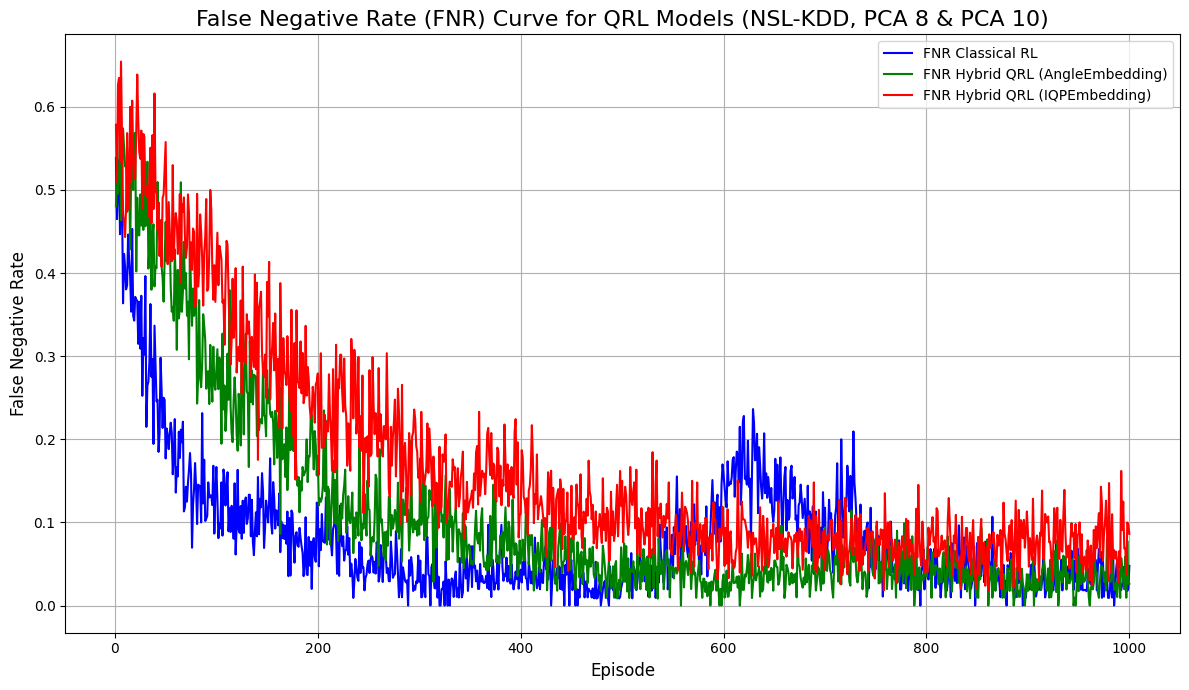

FNR curve plot saved to: /content/drive/MyDrive/phd3/outputs/NSLKDD_Resutls/AngleEmbedding/Angle-pca10/fnr_curve_NSLKDD_PCA10.png


In [17]:
import matplotlib.pyplot as plt
import os

# Define the output directory for saving the plot
output_plot_dir = '/content/drive/MyDrive/phd3/outputs/NSLKDD_Resutls/AngleEmbedding/Angle-pca10/'
os.makedirs(output_plot_dir, exist_ok=True)

plt.figure(figsize=(12, 7))

# Plot FNR Classical RL
plt.plot(fpr_fnr_classical_ae_pca10['Episode'], fpr_fnr_classical_ae_pca10['FNR_Classical'], label='FNR Classical RL', color='blue')

# Plot FNR Hybrid QRL (AngleEmbedding)
plt.plot(fpr_fnr_classical_ae_pca10['Episode'], fpr_fnr_classical_ae_pca10['FNR_Hybrid'], label='FNR Hybrid QRL (AngleEmbedding)', color='green')

# Plot FNR Hybrid QRL (IQPEmbedding)
plt.plot(fpr_fnr_hybrid_iqp_pca10['Episode'], fpr_fnr_hybrid_iqp_pca10['FNR_Hybrid'], label='FNR Hybrid QRL (IQPEmbedding)', color='red')

# Add title and labels
plt.title('False Negative Rate (FNR) Curve for QRL Models (NSL-KDD, PCA 8 & PCA 10)', fontsize=16)
plt.xlabel('Episode', fontsize=12)
plt.ylabel('False Negative Rate', fontsize=12)

# Add legend and grid
plt.legend(fontsize=10)
plt.grid(True)
plt.tight_layout()

# Save the plot
plot_path = os.path.join(output_plot_dir, 'fnr_curve_NSLKDD_PCA10.png')
plt.savefig(plot_path)

# Display the plot
plt.show()

print(f"FNR curve plot saved to: {plot_path}")

## Summary: FPR and FNR Analysis for QRL Models (NSL-KDD, PCA10)

### Observations from False Positive Rate (FPR) Curves:
*   **Classical RL (Blue Line)**: The FPR for the classical model starts relatively high but shows a general decreasing trend over episodes, indicating improved ability to correctly identify normal traffic while minimizing misclassifying normal traffic as attacks.
*   **Hybrid QRL (AngleEmbedding - Green Line)**: The FPR for the Hybrid QRL with AngleEmbedding also shows a decreasing trend, but often fluctuates more than the classical model. Its overall FPR performance appears to be higher than the classical model for many episodes, suggesting a higher rate of false alarms.
*   **Hybrid QRL (IQPEmbedding - Red Line)**: The FPR for the Hybrid QRL with IQPEmbedding generally performs comparably to or slightly better than the AngleEmbedding variant. It also shows a decreasing trend but with some volatility. It consistently has a higher FPR than the classical model, indicating more false alarms.

### Observations from False Negative Rate (FNR) Curves:
*   **Classical RL (Blue Line)**: The FNR for the classical model shows a general decreasing trend over episodes, signifying improvement in correctly identifying actual attacks and reducing the number of missed attacks. Its FNR is generally lower compared to both hybrid models, especially in later episodes.
*   **Hybrid QRL (AngleEmbedding - Green Line)**: The FNR for the Hybrid QRL with AngleEmbedding initially drops but then exhibits more significant fluctuations and generally settles at higher levels compared to the classical model. This suggests it might be missing more actual attacks.
*   **Hybrid QRL (IQPEmbedding - Red Line)**: The FNR for the Hybrid QRL with IQPEmbedding generally follows a similar trend to the AngleEmbedding variant, with noticeable fluctuations and higher rates compared to the classical model. It indicates a similar challenge in consistently detecting attacks.

### Overall Insights:
*   **Classical Model Advantage**: For the NSL-KDD dataset with PCA10, the Classical RL model generally demonstrates superior performance in both minimizing False Positive Rates (FPR) and False Negative Rates (FNR) compared to both Hybrid QRL models. This indicates that the classical approach is more effective in achieving a balance between avoiding false alarms and detecting actual attacks.
*   **Hybrid Model Volatility**: Both hybrid models (AngleEmbedding and IQPEmbedding) show more volatility in their FPR and FNR curves, suggesting less stable learning or a greater sensitivity to the training process. While they do learn and improve, their performance metrics are generally not as low or as stable as the classical counterpart.
*   **Embedding Strategy Impact**: Between the two hybrid embedding strategies, there isn't a stark difference, but IQPEmbedding might show slightly more stable FNR performance in some segments compared to AngleEmbedding. However, both fall short of the classical model's performance.

## Summary: FPR and FNR Analysis for QRL Models (NSL-KDD, PCA10)

### Observations from False Positive Rate (FPR) Curves:
*   **Classical RL (Blue Line)**: The FPR for the classical model starts relatively high but shows a general decreasing trend over episodes, indicating improved ability to correctly identify normal traffic while minimizing misclassifying normal traffic as attacks.
*   **Hybrid QRL (AngleEmbedding - Green Line)**: The FPR for the Hybrid QRL with AngleEmbedding also shows a decreasing trend, but often fluctuates more than the classical model. Its overall FPR performance appears to be higher than the classical model for many episodes, suggesting a higher rate of false alarms.
*   **Hybrid QRL (IQPEmbedding - Red Line)**: The FPR for the Hybrid QRL with IQPEmbedding generally performs comparably to or slightly better than the AngleEmbedding variant. It also shows a decreasing trend but with some volatility. It consistently has a higher FPR than the classical model, indicating more false alarms.

### Observations from False Negative Rate (FNR) Curves:
*   **Classical RL (Blue Line)**: The FNR for the classical model shows a general decreasing trend over episodes, signifying improvement in correctly identifying actual attacks and reducing the number of missed attacks. Its FNR is generally lower compared to both hybrid models, especially in later episodes.
*   **Hybrid QRL (AngleEmbedding - Green Line)**: The FNR for the Hybrid QRL with AngleEmbedding initially drops but then exhibits more significant fluctuations and generally settles at higher levels compared to the classical model. This suggests it might be missing more actual attacks.
*   **Hybrid QRL (IQPEmbedding - Red Line)**: The FNR for the Hybrid QRL with IQPEmbedding generally follows a similar trend to the AngleEmbedding variant, with noticeable fluctuations and higher rates compared to the classical model. It indicates a similar challenge in consistently detecting attacks.

### Overall Insights:
*   **Classical Model Advantage**: For the NSL-KDD dataset with PCA10, the Classical RL model generally demonstrates superior performance in both minimizing False Positive Rates (FPR) and False Negative Rates (FNR) compared to both Hybrid QRL models. This indicates that the classical approach is more effective in achieving a balance between avoiding false alarms and detecting actual attacks.
*   **Hybrid Model Volatility**: Both hybrid models (AngleEmbedding and IQPEmbedding) show more volatility in their FPR and FNR curves, suggesting less stable learning or a greater sensitivity to the training process. While they do learn and improve, their performance metrics are generally not as low or as stable as the classical counterpart.
*   **Embedding Strategy Impact**: Between the two hybrid embedding strategies, there isn't a stark difference, but IQPEmbedding might show slightly more stable FNR performance in some segments compared to AngleEmbedding. However, both fall short of the classical model's performance.

## Final Task

### Subtask:
Provide the generated plots and a summary of the observations from the FPR and FNR comparisons.


## Summary:

### Q&A
The observations from the FPR and FNR comparisons are summarized below:
*   **False Positive Rate (FPR) Observations:**
    *   **Classical RL:** Shows a generally decreasing FPR over episodes, indicating improved accuracy in identifying normal traffic.
    *   **Hybrid QRL (AngleEmbedding):** Exhibits higher FPR and more fluctuations compared to the classical model, suggesting more false alarms.
    *   **Hybrid QRL (IQPEmbedding):** Generally performs comparably or slightly better than AngleEmbedding but consistently has a higher FPR than the classical model, implying more false alarms.
*   **False Negative Rate (FNR) Observations:**
    *   **Classical RL:** Displays a decreasing FNR, indicating better detection of actual attacks and fewer missed threats, often outperforming hybrid models.
    *   **Hybrid QRL (AngleEmbedding):** Shows significant fluctuations and generally higher FNR compared to the classical model, suggesting more missed attacks.
    *   **Hybrid QRL (IQPEmbedding):** Follows a similar trend to AngleEmbedding with fluctuations and higher FNR rates than the classical model, indicating challenges in consistent attack detection.

### Data Analysis Key Findings
*   The `fpr_fnr_per_episode.csv` files for both AngleEmbedding and IQPEmbedding were successfully loaded into separate DataFrames.
*   A plot visualizing the False Positive Rate (FPR) curves for Classical RL, Hybrid QRL (AngleEmbedding), and Hybrid QRL (IQPEmbedding) was generated and saved as `fpr_curve_NSLKDD_PCA10.png`.
*   A plot visualizing the False Negative Rate (FNR) curves for the same three models was generated and saved as `fnr_curve_NSLKDD_PCA10.png`.
*   The Classical RL model demonstrated generally superior and more stable performance in minimizing both False Positive Rates and False Negative Rates compared to both Hybrid QRL models.
*   Both Hybrid QRL models (AngleEmbedding and IQPEmbedding) exhibited higher volatility and generally higher FPR and FNR values throughout the episodes compared to the classical approach.
*   Among the hybrid models, IQPEmbedding showed slightly more stable FNR performance in some segments compared to AngleEmbedding, though neither matched the performance of the classical model.

### Insights or Next Steps
*   The Classical RL model appears to be more effective for the NSL-KDD dataset with PCA10 features, suggesting it strikes a better balance between avoiding false alarms and detecting actual attacks.
*   Further research should focus on optimizing the architecture and training methodologies for Hybrid QRL models to improve their stability and reduce FPR and FNR to levels comparable to or better than classical approaches.


# **Correlations between features**

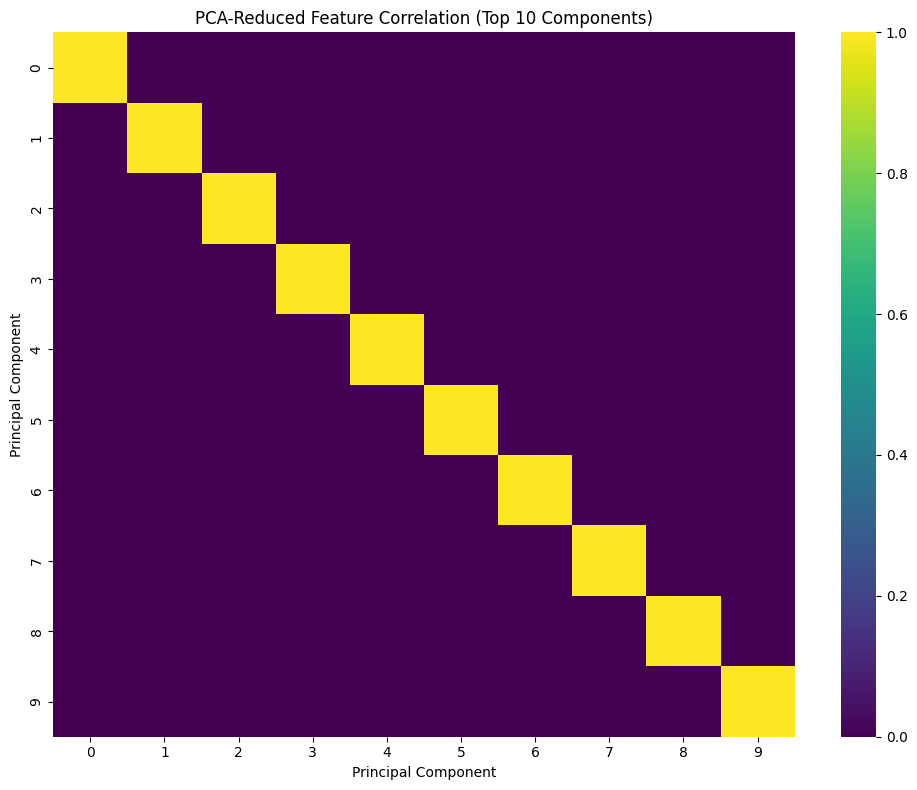

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import seaborn as sns

# ---- Load your dataset ----
#df = pd.read_csv("nsl_kdd.csv")   # or cicids.csv

# ---- Select only numerical features ----
numeric_df = df.select_dtypes(include=[np.number])

# ---- Standardization ----
scaler = StandardScaler()
scaled = scaler.fit_transform(numeric_df)

# ---- PCA reduction ----
pca = PCA(n_components=10) # Using 10 components as specified in the earlier variable `corr_matrix` in kernel state
pca_features = pca.fit_transform(X_scaled) # Using X_scaled from previous steps

# ---- Build correlation of PCA components ----
corr_matrix = np.corrcoef(pca_features.T)

# ---- Plot ----
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, cmap="viridis", annot=False)
plt.title("PCA-Reduced Feature Correlation (Top 10 Components)")
plt.xlabel("Principal Component")
plt.ylabel("Principal Component")
plt.tight_layout()
plt.savefig("correlation_pca10.png", dpi=400)
plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
# Fit the encoder to the 'attack' column of the original dataframe (df)
# Assuming df is still available and contains the 'attack' column as defined earlier in the notebook
label_encoder.fit(df['attack'])

print("Label names:")
print(label_encoder.classes_)

Label names:
['back' 'buffer_overflow' 'ftp_write' 'guess_passwd' 'imap' 'ipsweep'
 'land' 'loadmodule' 'multihop' 'neptune' 'nmap' 'normal' 'phf' 'pod'
 'portsweep' 'rootkit' 'satan' 'smurf' 'spy' 'teardrop' 'warezclient'
 'warezmaster']


### Correlation Matrix of Preprocessed Features

To show the correlation between the original features (including one-hot encoded categorical features), we will calculate the correlation matrix on the `X_encoded` DataFrame and visualize it with a heatmap.

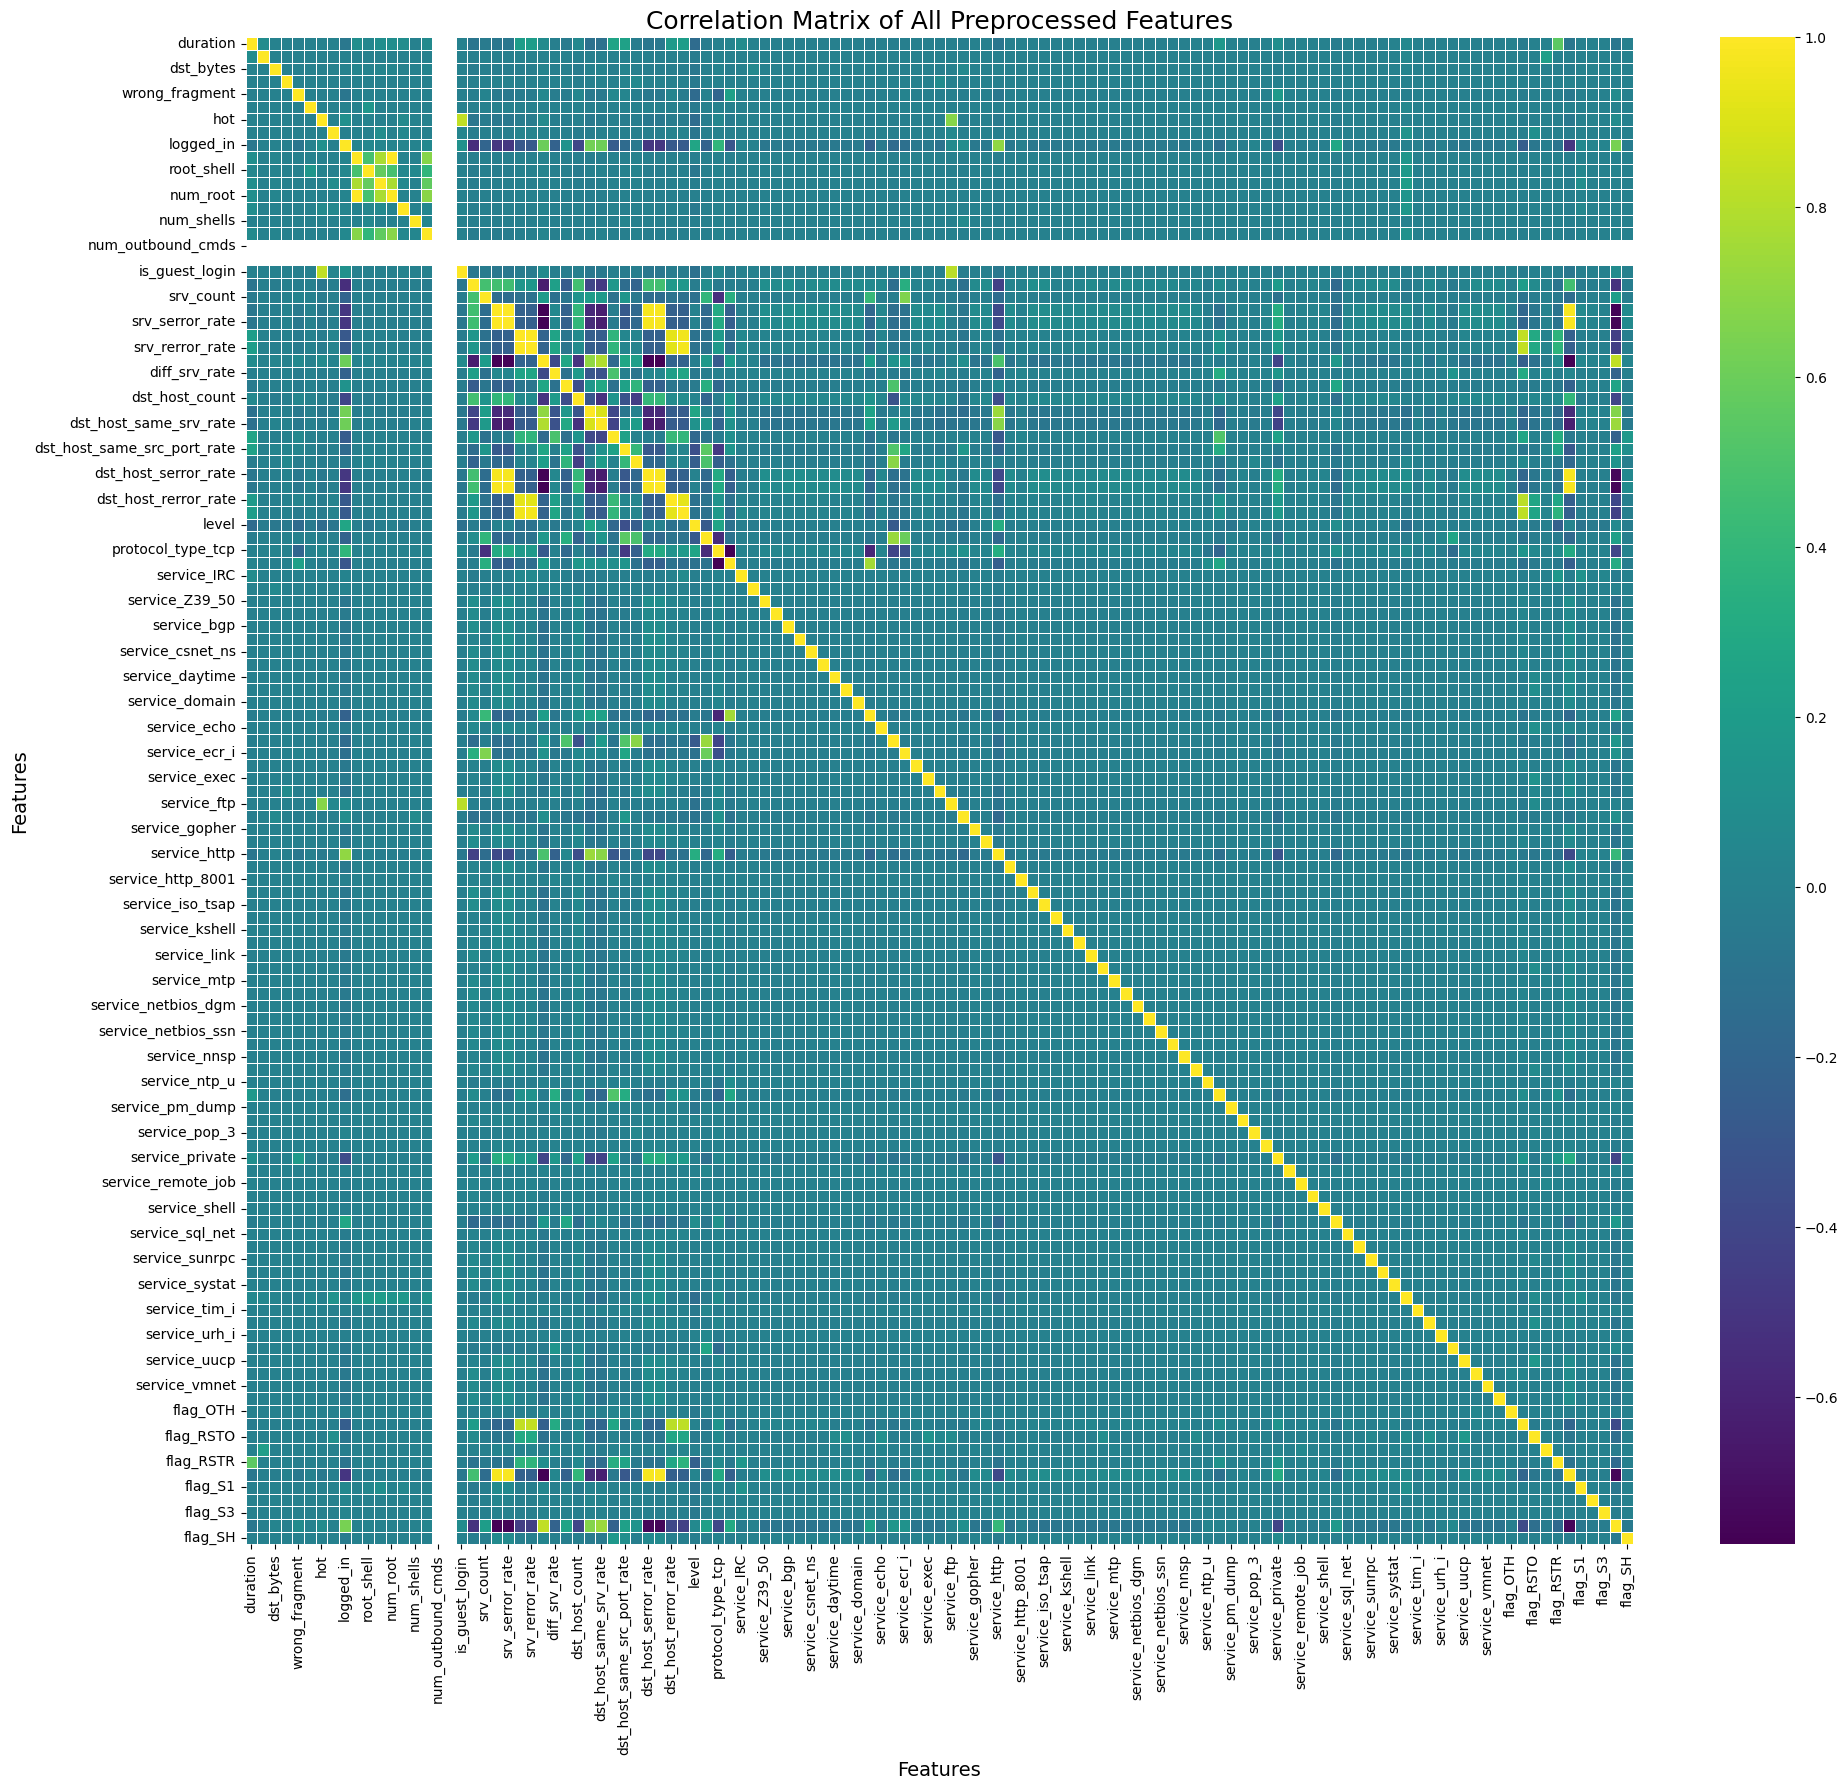

Generated heatmap of correlation matrix for preprocessed features.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Calculate the correlation matrix for the preprocessed features (X_encoded)
correlation_matrix_features = X_encoded.corr()

plt.figure(figsize=(20, 18)) # Adjust figure size for better readability of many features
sns.heatmap(correlation_matrix_features, cmap='viridis', annot=False, fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of All Preprocessed Features', fontsize=18)
plt.xlabel('Features', fontsize=14)
plt.ylabel('Features', fontsize=14)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/phd3/plots/correlation_matrix_features.png', dpi=300)
plt.show()

print("Generated heatmap of correlation matrix for preprocessed features.")